# ET0737 Machine Learning & AI — Mini Project
## Diabetes Risk Prediction from the CDC BRFSS 2015 Health Survey

**School of EEE, Singapore Polytechnic — AY26/27 S1**

**Dataset:** CDC *Behavioral Risk Factor Surveillance System (BRFSS) 2015*
— 441,456 US adults surveyed by telephone.
Source (raw): https://www.cdc.gov/brfss/annual_data/annual_2015.html
— Kaggle mirror: https://www.kaggle.com/datasets/cdc/behavioral-risk-factor-surveillance-system

We use `data/processed/diabetes_2015_clean.csv` — the tidy 240,184 × 34 table produced by
our companion notebook **`01_Diabetes_2015_Cleaning.ipynb`**.

---
### What this notebook does (the standard ML workflow)
1. **Load & understand** the cleaned data and *justify why each characteristic was kept*.
2. **Explore (EDA)** — class balance, distributions, and risk-factor relationships with Matplotlib/Seaborn.
3. **Preprocess** — feature engineering, one-hot encoding, scaling, and a leakage-safe **train / validation / test** split.
4. **Train & tune nine models spanning eight families** — Logistic Regression, a single Decision Tree, Random Forest, k-Nearest Neighbours, SVM (RBF), a **Neural Network (MLP)**, XGBoost and LightGBM, plus a **stacking ensemble** of four families under a **Logistic Regression meta-learner**. Each one is there to answer a question, not to pad the table.
5. **Evaluate & compare** — Accuracy, Precision, Recall, F1, ROC-AUC, confusion matrices, and an overfitting check with 5-fold cross-validation.
6. **Predict** on new patients + an **interactive risk calculator** (ipywidgets).
7. **Business insights**, a **Responsible-GenAI** reflection, and a **deployment export** used by the companion clinic web app.

> **Problem type:** binary **classification**.
> **Target `Diabetes`** = 1 if the respondent is *pre-diabetic or diabetic* (stage 1 or 2), else 0.
> This "at-risk screening" framing is the clinically useful question — *who should be
> referred for a blood-glucose test?* — and it is the standard framing for this dataset.

## 1 · Setup & Load the Cleaned Data

In [109]:
import os
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")   # silence loky's CPU-count probe on Win11

import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.ensemble import (RandomForestClassifier, StackingClassifier,
                              BaggingClassifier)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             RocCurveDisplay, ConfusionMatrixDisplay)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Parallelism budget: this machine has 8 cores but limited free RAM. We parallelise at
# exactly ONE level -- the cross-validation search -- and keep every estimator
# single-threaded (n_jobs=1). This avoids nested worker pools that would each copy the
# 144k-row training set and exhaust memory (the classic "kernel died" failure).
N_JOBS = 4

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
print("Libraries loaded: scikit-learn + XGBoost + LightGBM are the core ML toolkit here.")
print(f"Parallelism capped at N_JOBS={N_JOBS} (one level only) to stay within RAM.")

Libraries loaded: scikit-learn + XGBoost + LightGBM are the core ML toolkit here.
Parallelism capped at N_JOBS=4 (one level only) to stay within RAM.


In [110]:
df = pd.read_csv("../data/processed/diabetes_2015_clean.csv")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Shape: 240,184 rows x 34 columns


,DiabetesStage,HighBP,HighChol,CholCheck,BMI,BMICategory,Smoker,SmokerStatus,Stroke,HeartDiseaseorAttack,...,DiffWalk,Sex,Age,AgeYears,Race,MaritalStatus,Education,Income,Employment,CheckupTime
0,0,1,1,1,40.18,4,1,1,0,0,...,1,0,9,63,1,1,4,3,8,1
1,0,0,0,0,25.09,3,1,3,0,0,...,0,0,7,52,1,2,6,1,3,4
2,0,1,1,1,28.19,3,0,0,0,0,...,1,0,9,63,1,1,4,8,8,1
3,0,1,0,1,26.52,3,0,0,0,0,...,0,0,11,73,1,3,3,6,2,1
4,0,1,1,1,23.89,2,0,0,0,0,...,0,0,11,70,7,3,5,4,7,1


In [111]:
# Structure + basic statistics
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240184 entries, 0 to 240183
Data columns (total 34 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   DiabetesStage         240184 non-null  int64  
 1   HighBP                240184 non-null  int64  
 2   HighChol              240184 non-null  int64  
 3   CholCheck             240184 non-null  int64  
 4   BMI                   240184 non-null  float64
 5   BMICategory           240184 non-null  int64  
 6   Smoker                240184 non-null  int64  
 7   SmokerStatus          240184 non-null  int64  
 8   Stroke                240184 non-null  int64  
 9   HeartDiseaseorAttack  240184 non-null  int64  
 10  KidneyDisease         240184 non-null  int64  
 11  COPD                  240184 non-null  int64  
 12  Arthritis             240184 non-null  int64  
 13  Depression            240184 non-null  int64  
 14  PhysActivity          240184 non-null  int64  
 15  

In [112]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
DiabetesStage,240184.0,0.29,0.70,0.00,0.00,0.00,0.00,2.00
HighBP,240184.0,0.43,0.49,0.00,0.00,0.00,1.00,1.00
HighChol,240184.0,0.42,0.49,0.00,0.00,0.00,1.00,1.00
CholCheck,240184.0,0.96,0.19,0.00,1.00,1.00,1.00,1.00
BMI,240184.0,28.28,6.10,12.02,24.14,27.34,31.25,69.94
BMICategory,240184.0,2.99,0.81,1.00,2.00,3.00,4.00,4.00
Smoker,240184.0,0.44,0.50,0.00,0.00,0.00,1.00,1.00
SmokerStatus,240184.0,0.67,0.93,0.00,0.00,0.00,1.00,3.00
Stroke,240184.0,0.04,0.20,0.00,0.00,0.00,0.00,1.00
HeartDiseaseorAttack,240184.0,0.09,0.29,0.00,0.00,0.00,0.00,1.00


## 2 · Why We Kept These Characteristics (Feature Justification)

The raw BRFSS survey has **330 columns**. Our cleaning notebook deliberately kept only
**33 predictors + the target**. Every kept characteristic is an *established, medically
plausible correlate of type-2 diabetes* — this is **domain-driven feature selection**,
which beats blindly throwing 330 noisy survey codes at a model (that would invite
over-fitting and hurt interpretability). We reject variables that (a) are survey
admin/weighting fields, (b) belong to unrelated modules (cancer, HIV, caregiving), or
(c) would **leak the target** (e.g. *age at diabetes diagnosis*, *insulin use*, *blood-sugar
test result* — those are only recorded **because** the person already has diabetes).

| # | Feature | Type | Why it predicts diabetes |
|---|---------|------|--------------------------|
| 1 | **BMI** | continuous | Excess body fat is the single biggest modifiable driver of insulin resistance. |
| 2 | **AgeYears** | continuous | Risk rises steeply with age as β-cell function declines. |
| 3 | **HighBP** | binary | Hypertension clusters with diabetes in metabolic syndrome. |
| 4 | **HighChol / CholCheck** | binary | Dyslipidaemia co-occurs with insulin resistance. |
| 5 | **GenHlth** | ordinal 1–5 | Self-rated health is a strong general morbidity proxy. |
| 6 | **DiffWalk / PhysHlth / MentHlth** | mixed | Functional limitation & poor health-days track chronic disease burden. |
| 7 | **HeartDiseaseorAttack / Stroke / KidneyDisease / COPD / Arthritis** | binary | Comorbidities that share risk factors with (or result from) diabetes. |
| 8 | **Smoker / SmokerStatus** | binary/ordinal | Smoking raises type-2 diabetes risk. |
| 9 | **PhysActivity / PhysActivityLevel** | binary/ordinal | Inactivity worsens glucose control. |
| 10 | **Fruits / Veggies / HvyAlcoholConsump** | binary | Diet quality & heavy drinking affect metabolic risk. |
| 11 | **Sex** | binary | Prevalence differs by sex. |
| 12 | **Income / Education / Employment / MaritalStatus** | ordinal/nominal | Socio-economic status shapes diet, stress & healthcare access. |
| 13 | **AnyHealthcare / NoDocbcCost / CheckupTime** | binary/ordinal | Healthcare access affects diagnosis & management. |
| 14 | **Race** | nominal | Prevalence varies across ethnic groups (must be used carefully — see Responsible-AI note). |

**Redundancy we will remove in §4:** the dataset ships **four** near-duplicate pairs, each
a finer- and coarser-grained copy of the same signal: `BMI` vs `BMICategory` (band),
`AgeYears` vs `Age` (5-year band), `Smoker` (binary) vs `SmokerStatus` (ordinal), and
`PhysActivity` (binary) vs `PhysActivityLevel` (ordinal). Keeping both members of a pair is
multicollinear and adds no information, so we keep exactly one of each: the **continuous**
`BMI` / `AgeYears` (dropping the bands), and the **binary** `Smoker` / `PhysActivity`
(dropping the ordinal recodes). We keep the binaries rather than the ordinals because they
correlate at least as strongly with the target *and*, unlike an ordinal passed through
un-encoded, they impose no unverified linear spacing on the linear models — giving cleaner,
more stable logistic-regression coefficients.

In [113]:
# Data-quality gate: the cleaning notebook already dropped all Don't-know/Refused codes,
# so we confirm there are no missing values and no exact duplicate rows to worry about.
print("Missing values per column (should all be 0):")
print(df.isna().sum().sum(), "total missing cells")
print("Duplicate rows:", df.duplicated().sum())

Missing values per column (should all be 0):
0 total missing cells
Duplicate rows: 79


## 3 · Exploratory Data Analysis (EDA)

Before modelling we *look* at the data — the fastest way to catch imbalance, skew, and
whether the features actually relate to the target.

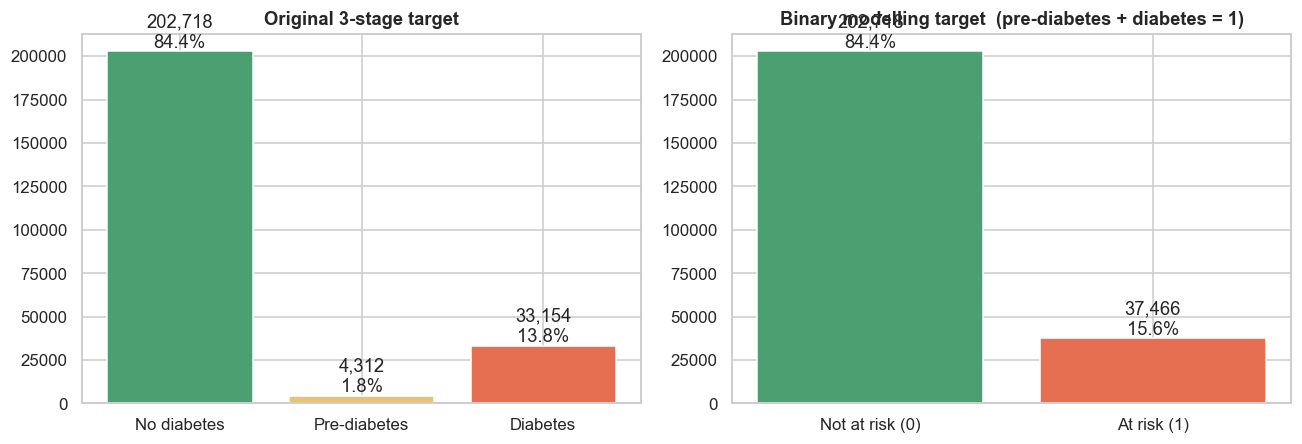

Positive (at-risk) rate: 15.6%  ->  this is an IMBALANCED problem.
=> Accuracy alone is misleading; we will emphasise Recall, F1 and ROC-AUC,
   and use class_weight='balanced' so the minority class is not ignored.


In [114]:
# --- Build the binary target: at-risk (pre-diabetes OR diabetes) = 1 ---
labels3 = {0: "No diabetes", 1: "Pre-diabetes", 2: "Diabetes"}
df["Diabetes"] = (df["DiabetesStage"] >= 1).astype(int)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
sc = df["DiabetesStage"].value_counts().sort_index()
ax[0].bar([labels3[i] for i in sc.index], sc.values, color=["#4C9F70", "#E9C46A", "#E76F51"])
ax[0].set_title("Original 3-stage target")
for i, v in enumerate(sc.values):
    ax[0].text(i, v, f"{v:,}\n{v/len(df):.1%}", ha="center", va="bottom")

bc = df["Diabetes"].value_counts().sort_index()
ax[1].bar(["Not at risk (0)", "At risk (1)"], bc.values, color=["#4C9F70", "#E76F51"])
ax[1].set_title("Binary modelling target  (pre-diabetes + diabetes = 1)")
for i, v in enumerate(bc.values):
    ax[1].text(i, v, f"{v:,}\n{v/len(df):.1%}", ha="center", va="bottom")
plt.tight_layout(); plt.show()

print(f"Positive (at-risk) rate: {df['Diabetes'].mean():.1%}  ->  this is an IMBALANCED problem.")
print("=> Accuracy alone is misleading; we will emphasise Recall, F1 and ROC-AUC,")
print("   and use class_weight='balanced' so the minority class is not ignored.")

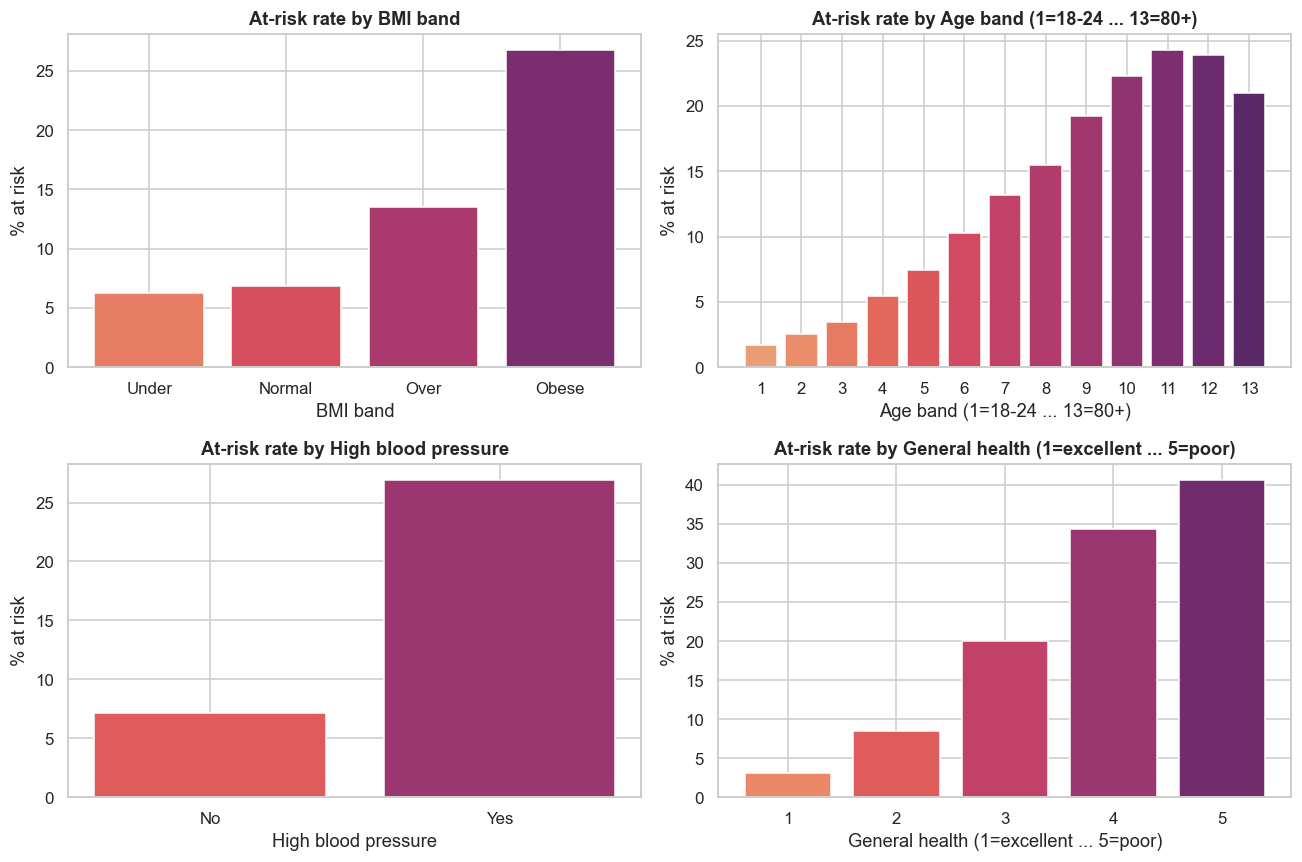

In [115]:
# Prevalence of diabetes/pre-diabetes across key risk factors — face-validity check
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
def prevalence_plot(ax, col, xlabel, xticklabels=None):
    p = df.groupby(col)["Diabetes"].mean() * 100
    ax.bar(p.index.astype(str), p.values, color=sns.color_palette("flare", len(p)))
    ax.set_title(f"At-risk rate by {xlabel}")
    ax.set_ylabel("% at risk"); ax.set_xlabel(xlabel)
    if xticklabels: ax.set_xticklabels(xticklabels, rotation=0)

prevalence_plot(axes[0,0], "BMICategory", "BMI band", ["Under", "Normal", "Over", "Obese"])
prevalence_plot(axes[0,1], "Age", "Age band (1=18-24 ... 13=80+)")
prevalence_plot(axes[1,0], "HighBP", "High blood pressure", ["No", "Yes"])
prevalence_plot(axes[1,1], "GenHlth", "General health (1=excellent ... 5=poor)")
plt.tight_layout(); plt.show()

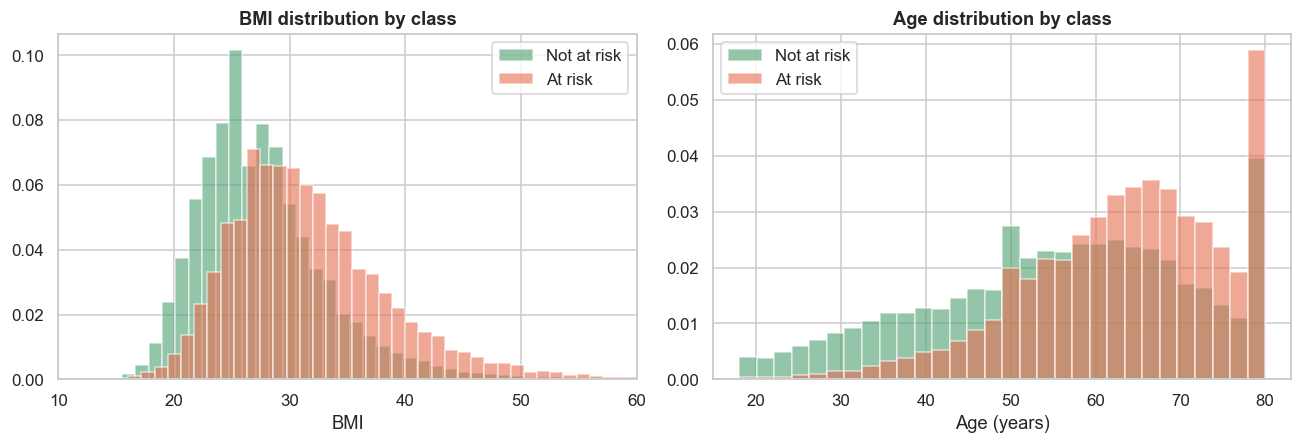

At-risk patients skew towards higher BMI and older age, exactly as clinical knowledge predicts.


In [116]:
# Distribution of the two key continuous features, split by class
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
for cls, colr, lab in [(0, "#4C9F70", "Not at risk"), (1, "#E76F51", "At risk")]:
    sub = df[df["Diabetes"] == cls]
    ax[0].hist(sub["BMI"], bins=50, alpha=0.6, density=True, color=colr, label=lab)
    ax[1].hist(sub["AgeYears"], bins=30, alpha=0.6, density=True, color=colr, label=lab)
ax[0].set_title("BMI distribution by class"); ax[0].set_xlabel("BMI"); ax[0].set_xlim(10, 60); ax[0].legend()
ax[1].set_title("Age distribution by class"); ax[1].set_xlabel("Age (years)"); ax[1].legend()
plt.tight_layout(); plt.show()
print("At-risk patients skew towards higher BMI and older age, exactly as clinical knowledge predicts.")

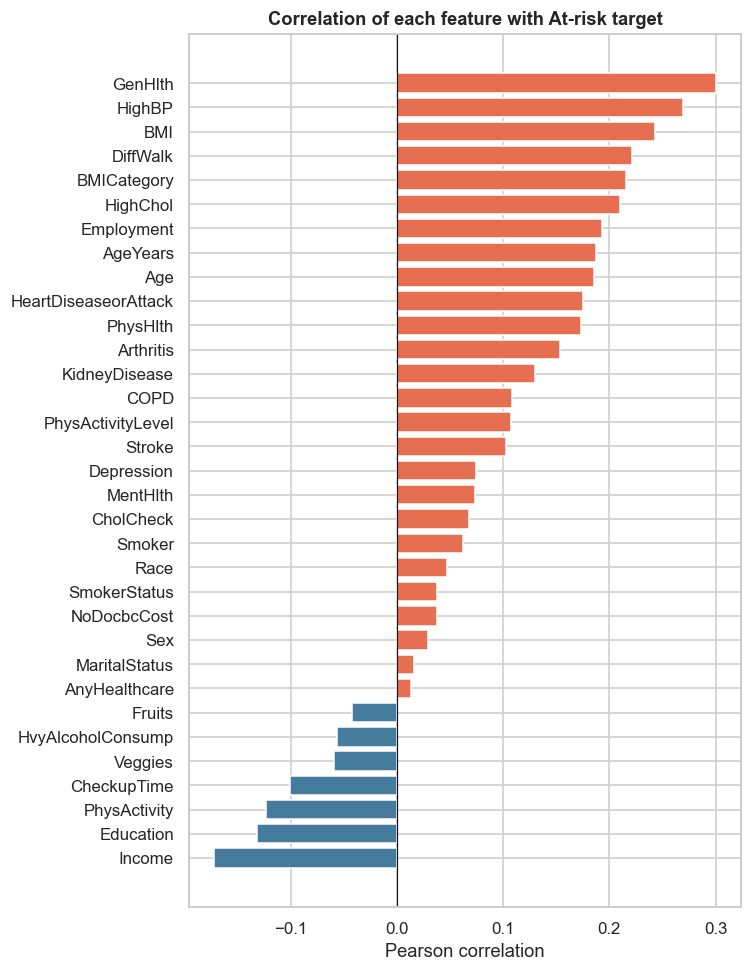

Strongest positive correlates: GenHlth, HighBP, BMI, DiffWalk, BMICategory


In [117]:
# Correlation of every feature with the target (point-biserial via Pearson on the binary target)
corr_target = df.drop(columns=["DiabetesStage"]).corr()["Diabetes"].drop("Diabetes").sort_values()
plt.figure(figsize=(7, 9))
colors = ["#E76F51" if v > 0 else "#457B9D" for v in corr_target.values]
plt.barh(corr_target.index, corr_target.values, color=colors)
plt.title("Correlation of each feature with At-risk target")
plt.xlabel("Pearson correlation"); plt.axvline(0, color="k", lw=0.8)
plt.tight_layout(); plt.show()
print("Strongest positive correlates:", ", ".join(corr_target.tail(5).index[::-1]))

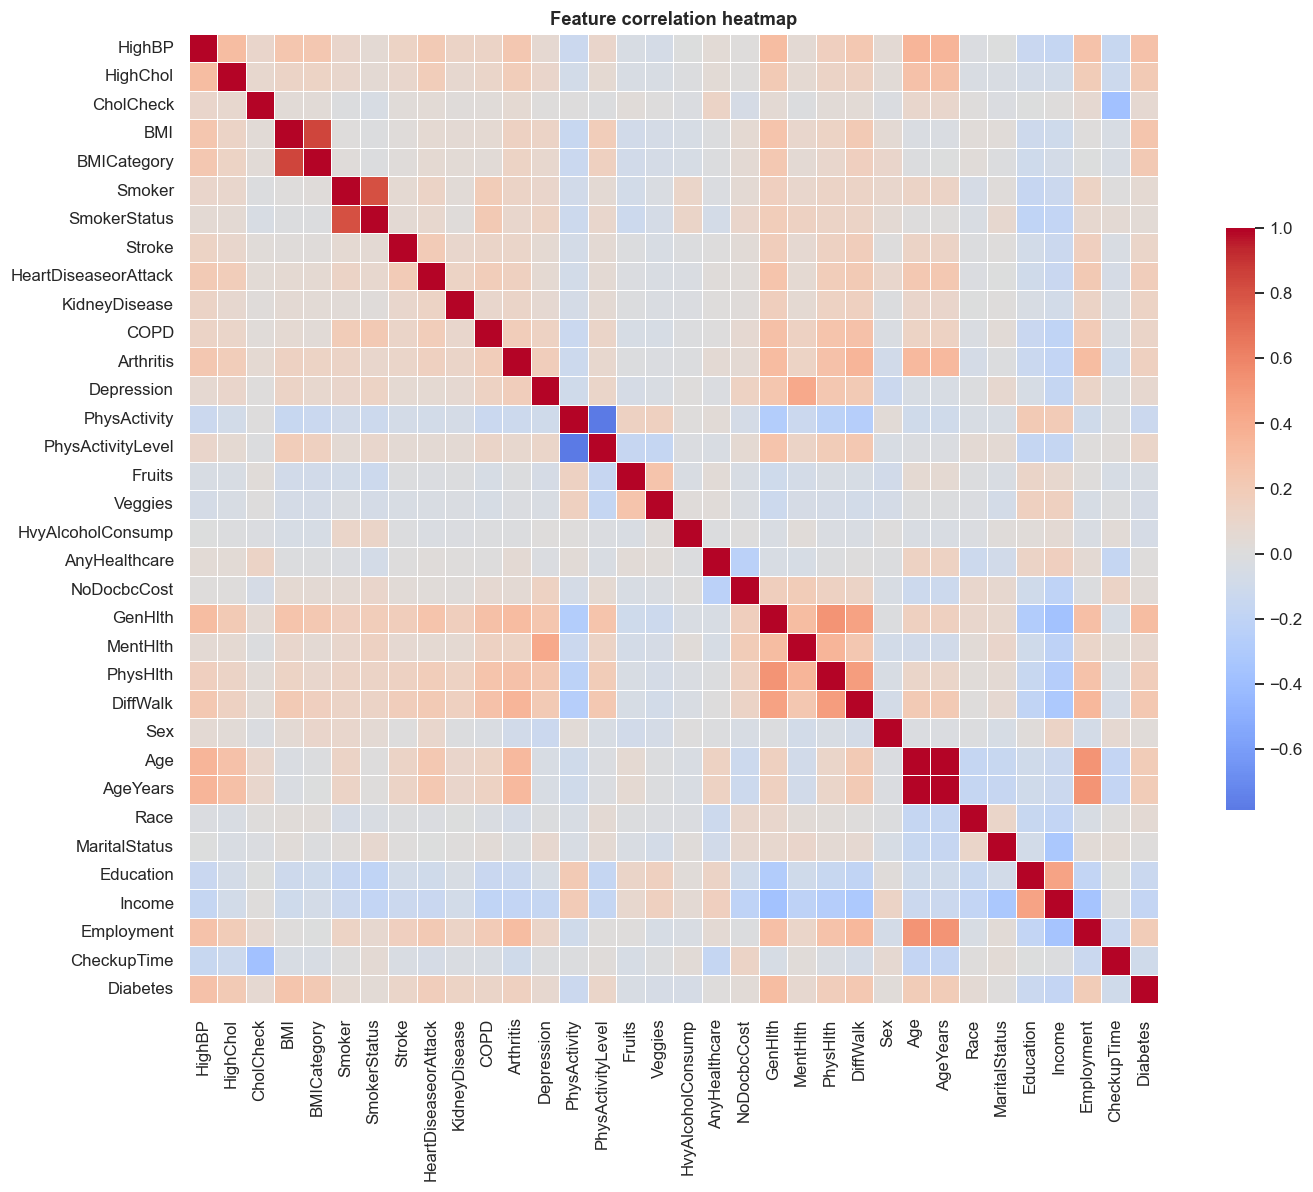

In [118]:
# Full correlation heatmap (spot multicollinearity). The dark off-diagonal blocks are the
# four near-duplicate pairs we deduplicate in §4: BMI/BMICategory, Age/AgeYears,
# Smoker/SmokerStatus, PhysActivity/PhysActivityLevel.
plt.figure(figsize=(14, 11))
sns.heatmap(df.drop(columns=["DiabetesStage"]).corr(), cmap="coolwarm", center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .6})
plt.title("Feature correlation heatmap")
plt.tight_layout(); plt.show()

## 4 · Preprocessing, Feature Engineering & Leakage-Safe Splitting

**Design choices (mapped to the rubric):**

* **Feature engineering / redundancy removal** — the survey ships four near-duplicate pairs
  (the dark blocks in the §3 heatmap). We keep one member of each and drop the other:
  drop the banded copies `Age` and `BMICategory` (lossy versions of continuous `AgeYears` /
  `BMI`), and drop the ordinal recodes `SmokerStatus` and `PhysActivityLevel`, keeping the
  binaries `Smoker` / `PhysActivity`. Keeping both members of a pair is multicollinear — it
  destabilises the logistic-regression coefficients and dilutes feature-importance scores.
  The binaries are kept over their ordinal twins because they correlate at least as strongly
  with the target and, passed through un-encoded, impose no unverified linear spacing.
* **Feature *types* drive the transform:**
  * *Continuous* (`BMI`, `AgeYears`, `MentHlth`, `PhysHlth`) → **StandardScaler**
    (required for the distance/gradient-based SVM & MLP; harmless for the others).
  * *Nominal / unordered* (`Race`, `MaritalStatus`, `Employment`) → **One-Hot Encoding**
    (their integer codes have no numeric order, so we must not let the model treat 3 > 2).
  * *Binary & ordinal* (HighBP, GenHlth, Income, …) → **passthrough** (already meaningful 0/1 or ranked integers).
* **Leakage prevention** — all transforms live **inside a `Pipeline`** and are `fit` on
  **training data only**. The scaler's mean/σ and the encoder's categories are learned
  from the train split, then merely *applied* to validation/test. We also split **before**
  any fitting.
* **Train / Validation / Test = 60 / 20 / 20**, *stratified* so the ~16 % positive rate
  is preserved in every split. Validation tunes/compares models; test is touched **once** at the end.

In [119]:
# Drop one member of each redundant near-duplicate pair (see §4 rationale + heatmap),
# plus the multiclass label; define X / y.
#   Age, BMICategory     -> banded copies of continuous AgeYears / BMI  (keep continuous)
#   SmokerStatus         -> ordinal recode of the Smoker binary         (keep binary)
#   PhysActivityLevel    -> ordinal recode of the PhysActivity binary   (keep binary)
X = df.drop(columns=["DiabetesStage", "Diabetes",
                     "Age", "BMICategory",
                     "SmokerStatus", "PhysActivityLevel"])
y = df["Diabetes"]

numeric_features = ["BMI", "AgeYears", "MentHlth", "PhysHlth"]
nominal_features = ["Race", "MaritalStatus", "Employment"]
passthrough_features = [c for c in X.columns if c not in numeric_features + nominal_features]

print(f"{X.shape[1]} predictors ->")
print(" scaled  :", numeric_features)
print(" one-hot :", nominal_features)
print(" as-is   :", passthrough_features)

29 predictors ->
 scaled  : ['BMI', 'AgeYears', 'MentHlth', 'PhysHlth']
 one-hot : ['Race', 'MaritalStatus', 'Employment']
 as-is   : ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'KidneyDisease', 'COPD', 'Arthritis', 'Depression', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'DiffWalk', 'Sex', 'Education', 'Income', 'CheckupTime']


In [120]:
# 60/20/20 stratified split (train -> then split temp into val/test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, stratify=y, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE)

for name, yy in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    print(f"{name:5s}: {len(yy):>7,} rows | positive rate {yy.mean():.1%}")

Train: 144,110 rows | positive rate 15.6%
Val  :  48,037 rows | positive rate 15.6%
Test :  48,037 rows | positive rate 15.6%


In [121]:
# One preprocessor, reused by every model pipeline -> guarantees identical, leakage-free prep
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), nominal_features),
    ("pass", "passthrough", passthrough_features),
])
print("Preprocessor built (StandardScaler + OneHotEncoder + passthrough).")

Preprocessor built (StandardScaler + OneHotEncoder + passthrough).


## 5 · Model Development & Tuning

We train **nine models spanning eight families** on the leakage-safe split from §4. Every one of
them is tuned by cross-validated hyper-parameter search scored on **ROC-AUC** — threshold-independent,
and therefore the right objective on a 16 %-positive target where accuracy is meaningless and any
fixed cut-off flatters whichever model happens to be aggressive.

**Every entry answers a question.** A roster is only worth its runtime if each model is there to
settle something the others cannot. The single Decision Tree (§5.2) is the control that makes the
bagging and boosting claims testable; k-NN (§5.4) asks whether risk is *local*; the two boosters
(§5.7–§5.8) grow trees in incompatible ways, so their agreement measures the data rather than a
library. Four further candidates — Extra Trees, HistGradientBoosting, Gaussian Naive Bayes and an
SVM-on-PCA arm — were built, measured, and then **cut**: they landed on the same ROC-AUC as models
already on the board and so added runtime without adding evidence. That deletion is recorded in
§11 as a result, not hidden as a tidy-up.

**One code path, nine models.** §5.0 defines a single `train_model()` helper that builds the
pipeline, runs the search, records train/validation metrics and prints a uniform one-line report.
Every model cell below is therefore just *which estimator* and *which hyper-parameters to try* —
typically four lines. That is not cosmetic: because the helper is the only place a pipeline is
constructed, it is impossible for one model to accidentally get different preprocessing, a different
CV protocol, or a different scoring metric from another. The comparison in §6 is like-for-like by
construction rather than by careful proof-reading.

| § | Model | Family | Why it is in the roster |
|---|-------|--------|-------------------------|
| 5.1 | **Logistic Regression** | linear | transparent baseline; its coefficients are directly interpretable |
| 5.2 | **Decision Tree** | single tree | the atom bagging and boosting are built from — without it, "the ensemble is better" is untestable |
| 5.3 | **Random Forest** | bagged trees | strong low-variance ensemble on tabular data, and it yields feature importances |
| 5.4 | **k-Nearest Neighbours** | instance-based | the only non-parametric entry — tests whether risk is *local*, i.e. whether similar answers share an outcome |
| 5.5 | **SVM (RBF)** | kernel | smooth non-linear boundaries in the scaled feature space |
| 5.6 | **Neural Network (MLP)** | neural | a feed-forward net *learns* its own feature interactions instead of us hand-crafting them |
| 5.7 | **XGBoost** | boosted trees (level-wise) | usually the top single model on tabular health data |
| 5.8 | **LightGBM** | boosted trees (leaf-wise) | grows the *highest-loss* leaf rather than a whole level — a genuinely different tree shape |
| 5.9 | **Stacking ensemble** | ensemble of four families | XGBoost + Random Forest + SVM + Logistic Regression → Logistic Regression meta-learner |

§5.10 closes the section with **PCA as a diagnostic** — not a tenth model. It is what explains
*why* all nine plateau together.

**Why two boosters rather than one.** XGBoost and LightGBM are both gradient boosting, but they
differ in the one decision that shapes a boosted model: how a tree is grown. XGBoost grows
level-wise on exact/approximate splits; LightGBM grows leaf-wise, always splitting whichever leaf
reduces the loss most. If two implementations that disagree that fundamentally land on the same
score, that is strong evidence the ceiling belongs to the **data** and not to any implementation —
which is exactly the question §6 and §5.10 set out to answer.

Every model appends to the shared `results` / `fitted` / `tuned` objects, so the comparison, ROC
curves and final test evaluation in §6–§7 pick all nine up automatically.


In [122]:
# ============================================================================
# 5.0 · The one code path every model in this section goes through
# ----------------------------------------------------------------------------
# Two helpers and three registries. `train_model()` is the important one: it BUILDS the
# pipeline, RUNS the search, REGISTERS the winner and REPORTS it, so a model cell below only
# has to name an estimator and a hyper-parameter space. Because this is the only place a
# pipeline is assembled, every model provably gets the same preprocessing, the same
# StratifiedKFold(3), the same roc_auc scoring and the same train/validation metric rows --
# the §6 comparison is like-for-like by construction, not by inspection.
#
# clone(preprocessor) rather than the shared object: each pipeline owns a private copy, so
# nothing that is fitted here can ever mutate a preprocessor another model is already using.

def evaluate(model, X_, y_, name, split):
    """The full metric suite for a fitted estimator on one split."""
    pred  = model.predict(X_)
    proba = model.predict_proba(X_)[:, 1]
    return {
        "Model": name, "Split": split,
        "Accuracy":  accuracy_score(y_, pred),
        "Precision": precision_score(y_, pred, zero_division=0),
        "Recall":    recall_score(y_, pred),
        "F1":        f1_score(y_, pred),
        "ROC-AUC":   roc_auc_score(y_, proba),
    }


def train_model(name, estimator, params=None, *, n_iter=None, pca=None, data=None):
    """Tune one model, register it, and print a uniform one-line report.

    name      -- the label used everywhere downstream (§6 tables, ROC curves, export)
    estimator -- an unfitted classifier; it becomes the "clf" step of the pipeline
    params    -- hyper-parameter space keyed "clf__<param>"; None/empty means a plain fit
    n_iter    -- if given, RandomizedSearchCV with this budget; otherwise exhaustive GridSearchCV
    pca       -- number of principal components to insert between preprocessing and the model
    data      -- (X, y) to fit on; defaults to the full training split (used by the SVMs,
                 which are O(n^2) and therefore tuned on a stratified subsample)
    """
    X_fit, y_fit = data if data is not None else (X_train, y_train)

    steps = [("prep", clone(preprocessor))]
    if pca:
        steps.append(("pca", PCA(n_components=pca, random_state=RANDOM_STATE)))
    steps.append(("clf", estimator))
    pipe = Pipeline(steps)

    t0 = time.perf_counter()
    if not params:                                     # nothing to tune -> straight fit
        best, best_params, cv_auc = pipe.fit(X_fit, y_fit), {}, np.nan
    else:
        Search = RandomizedSearchCV if n_iter else GridSearchCV
        extra  = {"n_iter": n_iter, "random_state": RANDOM_STATE} if n_iter else {}
        search = Search(pipe, params, scoring="roc_auc", cv=cv, n_jobs=N_JOBS, **extra)
        search.fit(X_fit, y_fit)
        best, best_params, cv_auc = search.best_estimator_, search.best_params_, search.best_score_
    mins = (time.perf_counter() - t0) / 60

    fitted[name] = best
    # Strip the "clf__" prefix so the tuned values can be fed straight back into a bare
    # estimator -- which is exactly what the stacking ensemble in §5.9 does.
    tuned[name] = {k.replace("clf__", ""): v for k, v in best_params.items()}
    results.append(evaluate(best, X_fit, y_fit, name, "Train"))
    results.append(evaluate(best, X_val,  y_val,  name, "Val"))

    val = results[-1]
    cv_txt = f"{cv_auc:.4f}" if cv_auc == cv_auc else " n/a  "   # n/a when nothing was tuned
    print(f"{name:<22} | CV AUC {cv_txt} | val AUC {val['ROC-AUC']:.4f} "
          f"| val recall {val['Recall']:.3f} | fit {mins:4.1f} min on {len(X_fit):,} rows")
    if tuned[name]:
        print(f"{'':22} | best: {tuned[name]}")
    return best


cv      = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
results = []          # train/val metric rows, one per model per split
fitted  = {}          # name -> the tuned, fitted pipeline
tuned   = {}          # name -> its winning hyper-parameters (reused by the §5.9 ensemble)
print("Shared training helper ready -- every model below is 4-8 lines because of it.")

Shared training helper ready -- every model below is 4-8 lines because of it.


In [123]:
# ---------- 5.1  Logistic Regression (linear baseline) ----------
# The reference point for the whole roster. It is the only model whose decision rule can be read
# straight off the coefficients (§7), so if something far more complex barely beats it, that is a
# finding about the data rather than a reason to ship the complex thing. L1 vs L2 is tuned because
# they answer different questions: L1 zeroes weak features out, L2 shrinks them.
train_model("Logistic Regression",
            LogisticRegression(max_iter=2000, class_weight="balanced",
                               solver="liblinear", random_state=RANDOM_STATE),
            {"clf__C": [0.01, 0.1, 1, 10], "clf__penalty": ["l1", "l2"]})

Logistic Regression    | CV AUC 0.8262 | val AUC 0.8238 | val recall 0.762 | fit  2.1 min on 144,110 rows
                       | best: {'C': 0.1, 'penalty': 'l2'}


,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [124]:
# ---------- 5.2  Decision Tree (a single, readable CART) ----------
# The atom that §5.3 and §§5.7-5.8 are built from. Bagging and boosting are both CLAIMS about what
# averaging -- or sequentially correcting -- MANY trees buys over ONE, and that claim is untestable
# without a single tuned tree on the same board. This is the control that makes those sections mean
# something: the train-vs-validation F1 gap in §6.4b's transparency board is where a lone tree's
# variance shows up as a measured number rather than as a warning in a textbook.
#
# Left unbounded, a tree will carve 144k rows into pure leaves and memorise the noise in
# self-reported survey answers, so both capacity dials are tuned rather than defaulted: max_depth
# caps how many questions may be chained, min_samples_leaf forbids leaves resting on a handful of
# patients. criterion is tuned too -- gini and entropy genuinely disagree about which split is best
# on skewed classes. class_weight="balanced" gives it the same imbalance fix as the rest of the
# roster, so its 0.50 cut-off is comparable with theirs.
train_model("Decision Tree",
            DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE),
            {"clf__max_depth": [4, 6, 8, 12],
             "clf__min_samples_leaf": [20, 50, 200],
             "clf__criterion": ["gini", "entropy"]})


Decision Tree          | CV AUC 0.8130 | val AUC 0.8143 | val recall 0.785 | fit  0.4 min on 144,110 rows
                       | best: {'criterion': 'entropy', 'max_depth': 12, 'min_samples_leaf': 200}


,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [78]:
# ---------- 5.3  Random Forest (bagged trees) ----------
# NOTE ON MEMORY: the forest's own n_jobs=1. Parallelism happens only in the search (n_jobs=N_JOBS).
# If both parallelised we would spawn nested worker pools, each copying the 144k-row training set
# -> out of memory. max_depth stays bounded (never None): that caps memory AND is the correct
# overfitting control for a forest on 240k noisy survey rows.
train_model("Random Forest",
            RandomForestClassifier(class_weight="balanced_subsample",
                                   random_state=RANDOM_STATE, n_jobs=1),
            {"clf__n_estimators": [150, 250, 350],
             "clf__max_depth": [10, 16, 22],
             "clf__min_samples_leaf": [5, 10, 20],
             "clf__max_features": ["sqrt", 0.5]},
            n_iter=8)

Random Forest          | CV AUC 0.8287 | val AUC 0.8282 | val recall 0.752 | fit 10.6 min on 144,110 rows
                       | best: {'n_estimators': 350, 'min_samples_leaf': 20, 'max_features': 'sqrt', 'max_depth': 22}


,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [79]:
# ---------- 5.4  k-Nearest Neighbours (instance-based, "lazy" learning) ----------
# The one model here that never builds a model. Fitting just stores the rows; a prediction is a vote
# among the k most similar patients in the scaled feature space. That makes it a direct test of a
# question every model above answers only implicitly: is diabetes risk LOCAL -- do people who
# answered the questionnaire alike actually share an outcome?
#
# Three things make it an honest entry rather than a decorative one:
#   * StandardScaler is load-bearing here, not hygiene. A distance is meaningless if BMI (12-98) and
#     a 0/1 indicator share an axis untouched, so the shared preprocessor is what makes k-NN work at
#     all -- the same preprocessing that is merely convenient for the trees.
#   * "distance" weighting is tuned against a uniform vote: with k in the tens on a 16 %-positive
#     target, a uniform vote rarely returns a majority for the minority class at all.
#   * p=1 (Manhattan) vs p=2 (Euclidean) is tuned because most columns here are binary, and on a
#     mostly-binary space Manhattan distance is simply a COUNT OF DISAGREEING ANSWERS -- arguably a
#     more faithful notion of "a similar patient" than a straight line through that space.
#
# NOTE ON IMBALANCE: like the MLP in §5.6, KNeighborsClassifier has NO class_weight, so it trains
# imbalance-naive and will look weak on recall at the arbitrary 0.50 cut-off. §6.4 re-scores every
# model at a MATCHED recall, which is the comparison that treats it fairly.
#
# THE SHARED SUBSAMPLE. Both distance-based models are fitted on the same 15,000-row STRATIFIED
# subsample, for two different reasons. The RBF-SVM in §5.5 is O(n^2) to FIT. k-NN is instantaneous
# to fit but pays at PREDICT time -- and, more decisively, a lazy learner's "model" IS its training
# set: deploying one trained on 144k rows means shipping 144k patient records to the clinic inside
# the artifact. Stratifying preserves the ~16 % positive rate so both models' metrics stay
# representative, and §6.4b excludes both from deployment on exactly this ground.
X_sub, _, y_sub, _ = train_test_split(
    X_train, y_train, train_size=15000, stratify=y_train, random_state=RANDOM_STATE)
print(f"Distance-based models (§5.4, §5.5) share one stratified {len(X_sub):,}-row subsample: "
      f"{y_sub.mean():.1%} positive vs {y_train.mean():.1%} in the full training split.\n")

train_model("k-Nearest Neighbours",
            KNeighborsClassifier(n_jobs=1),
            {"clf__n_neighbors": [25, 50, 100],
             "clf__weights": ["uniform", "distance"],
             "clf__p": [1, 2]},
            data=(X_sub, y_sub))


Distance-based models (§5.4, §5.5) share one stratified 15,000-row subsample: 15.6% positive vs 15.6% in the full training split.

k-Nearest Neighbours   | CV AUC 0.8160 | val AUC 0.8065 | val recall 0.045 | fit  0.3 min on 15,000 rows
                       | best: {'n_neighbors': 100, 'p': 1, 'weights': 'distance'}


,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [80]:
# ---------- 5.5  SVM (RBF kernel) on the shared 15k subsample ----------
# A full RBF-SVM is O(n^2) in rows and impractical on 144k of them, so it is tuned on the same
# stratified subsample §5.4 built -- a standard, honest engineering trade-off, stated rather than
# hidden. Reusing the identical X_sub / y_sub as k-NN is deliberate: the two distance-based models
# then differ only in HOW THEY USE the geometry, never in what data they saw.
train_model("SVM (RBF)",
            SVC(kernel="rbf", class_weight="balanced", probability=True,
                random_state=RANDOM_STATE),
            {"clf__C": [0.5, 1, 5], "clf__gamma": ["scale", 0.05]},
            data=(X_sub, y_sub))

SVM (RBF)              | CV AUC 0.8318 | val AUC 0.8224 | val recall 0.790 | fit  5.4 min on 15,000 rows
                       | best: {'C': 0.5, 'gamma': 'scale'}


,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [81]:
# ---------- 5.6  Neural Network (Multi-Layer Perceptron) ----------
# The neural entry: a feed-forward network that LEARNS its own non-linear feature interactions by
# back-propagation instead of us hand-crafting them. It reuses the same leakage-safe preprocessor,
# which matters more here than for the trees -- gradient descent needs the standardised inputs
# StandardScaler provides, or the wide-range features (BMI, AgeYears) dominate the first-layer
# gradients and training stalls.
#   * the grid trades network capacity (hidden_layer_sizes) against alpha, the L2 weight penalty.
#   * early_stopping=True holds out 10% of the training rows internally and halts once the internal
#     validation score stops improving -- the network's own overfitting control, safer than a fixed
#     epoch count, and it keeps the search fast.
#   * a small batch (256) with a modest learning rate (1e-3) and patience 10 is what actually gets
#     this net to a competitive ROC-AUC; with a large batch / high rate it stops after ~8 epochs
#     while still badly under-trained.
#
# NOTE ON IMBALANCE: unlike every other model here, MLPClassifier has NO class_weight parameter, so
# the network trains imbalance-naive and will look weak on RECALL at the arbitrary 0.50 cut-off (it
# rarely crosses 0.50 for a 16% minority class). That is a THRESHOLD artefact, not a modelling
# failure -- we compare on threshold-independent ROC-AUC, and §6.4 re-scores every model at a
# MATCHED recall, which is where this becomes visible.
train_model("Neural Network (MLP)",
            MLPClassifier(activation="relu", solver="adam", batch_size=256,
                          learning_rate_init=1e-3, early_stopping=True,
                          n_iter_no_change=10, max_iter=120, random_state=RANDOM_STATE),
            {"clf__hidden_layer_sizes": [(64, 32), (128, 64)], "clf__alpha": [1e-4, 1e-3]})

Neural Network (MLP)   | CV AUC 0.8290 | val AUC 0.8270 | val recall 0.162 | fit  0.8 min on 144,110 rows
                       | best: {'alpha': 0.001, 'hidden_layer_sizes': (64, 32)}


,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


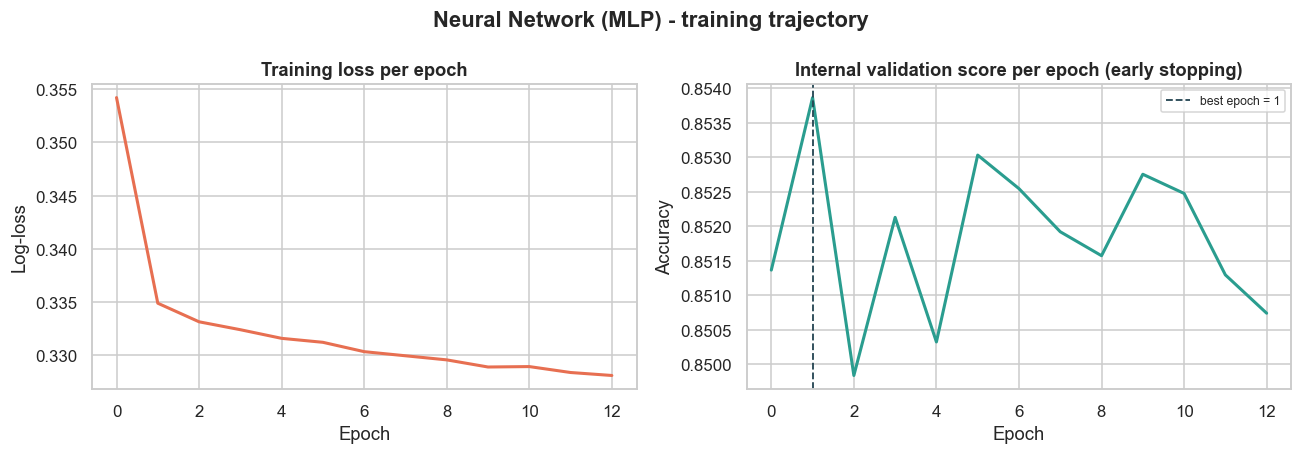

Architecture: 48 inputs -> (64, 32) hidden (ReLU) -> 1 sigmoid output
Training stopped at epoch 13: the internal validation score had not improved
for 10 consecutive epochs, so the weights were rolled back to the
best epoch (internal validation score 0.8539). This is the
network's built-in overfitting guard.


In [82]:
# --- 5.6b  Training curve: does the network actually learn, and when does it stop? ---
# The MLP is the one model here with an explicit training TRAJECTORY, so we plot it. loss_curve_ is
# the training loss per epoch; validation_scores_ is the accuracy on the 10% the network held out
# for early stopping. The gap between "still falling" and "stopped improving" is exactly what
# early_stopping detects -- visual proof the model is not trained to overfit.
best_mlp = fitted["Neural Network (MLP)"].named_steps["clf"]
n_inputs = fitted["Neural Network (MLP)"].named_steps["prep"].transform(X_train[:1]).shape[1]

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].plot(best_mlp.loss_curve_, color="#E76F51", lw=2)
ax[0].set_title("Training loss per epoch"); ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Log-loss")
ax[1].plot(best_mlp.validation_scores_, color="#2A9D8F", lw=2)
ax[1].axvline(int(np.argmax(best_mlp.validation_scores_)), ls="--", lw=1.2, color="#264653",
              label=f"best epoch = {int(np.argmax(best_mlp.validation_scores_))}")
ax[1].set_title("Internal validation score per epoch (early stopping)")
ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("Accuracy"); ax[1].legend(fontsize=8)
fig.suptitle("Neural Network (MLP) - training trajectory", fontweight="bold")
plt.tight_layout(); plt.show()

print(f"Architecture: {n_inputs} inputs -> {best_mlp.hidden_layer_sizes} hidden (ReLU) -> 1 sigmoid output")
print(f"Training stopped at epoch {best_mlp.n_iter_}: the internal validation score had not improved")
print(f"for {best_mlp.n_iter_no_change} consecutive epochs, so the weights were rolled back to the")
print(f"best epoch (internal validation score {best_mlp.best_validation_score_:.4f}). This is the")
print("network's built-in overfitting guard.")

### 5.7–5.8 · Gradient boosting, two different ways

Both of the next two cells are **gradient boosting** — fit a tree to the current errors, add it to
the ensemble, repeat — but they disagree about the single decision that shapes a boosted model:
*how do you grow the next tree?*

* **XGBoost (§5.7)** grows **level-wise**: every node at a depth is split before moving deeper, on
  split points found from the sorted feature values. `max_depth` is the capacity dial.
* **LightGBM (§5.8)** grows **leaf-wise**: it splits whichever leaf in the whole tree reduces the
  loss most, so trees come out deep and lopsided rather than balanced. `num_leaves` replaces
  `max_depth` as the capacity dial, and it overfits faster if that dial is left alone.

Each handles the 16 % imbalance in its own idiom — `scale_pos_weight` for XGBoost,
`class_weight="balanced"` for LightGBM — so **no resampling is needed anywhere in this notebook**.
Two independent implementations of the same idea is a deliberate control: where two libraries that
disagree about tree shape still converge on the same ROC-AUC, the ceiling belongs to the
questionnaire rather than to any one library's growth strategy.


In [83]:
# ---------- 5.7  XGBoost (level-wise boosted trees) ----------
# scale_pos_weight = (#negatives / #positives) tells XGBoost to weight the minority class, so no
# resampling is needed -- a clean, fast route to the imbalance fix. tree_method='hist' keeps it fast
# and memory-light on 144k rows. The estimator stays single-threaded; only the search parallelises
# (the same one-level-parallelism rule as §5.3).
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Class imbalance: scale_pos_weight = {scale_pos_weight:.2f} negatives per positive\n")

train_model("XGBoost",
            XGBClassifier(objective="binary:logistic", eval_metric="logloss", tree_method="hist",
                          scale_pos_weight=scale_pos_weight, n_jobs=1, random_state=RANDOM_STATE),
            {"clf__n_estimators": [300, 500, 800], "clf__max_depth": [3, 4, 6],
             "clf__learning_rate": [0.03, 0.05, 0.1], "clf__subsample": [0.8, 1.0],
             "clf__colsample_bytree": [0.8, 1.0], "clf__min_child_weight": [1, 5]},
            n_iter=10)

Class imbalance: scale_pos_weight = 5.41 negatives per positive

XGBoost                | CV AUC 0.8321 | val AUC 0.8301 | val recall 0.791 | fit  2.2 min on 144,110 rows
                       | best: {'subsample': 1.0, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.03, 'colsample_bytree': 0.8}


,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [84]:
# ---------- 5.8  LightGBM (leaf-wise boosted trees) ----------
# The third boosting idiom: grow whichever LEAF reduces the loss most, anywhere in the tree, instead
# of completing each level. Trees end up deep and lopsided, which fits sharp interactions with fewer
# splits -- and overfits faster if left unchecked, so num_leaves and min_child_samples are the dials
# that matter and both are tuned. verbose=-1 silences its per-iteration chatter; n_jobs=1 keeps the
# one-level-parallelism rule.
train_model("LightGBM",
            LGBMClassifier(objective="binary", class_weight="balanced", n_estimators=500,
                           n_jobs=1, verbose=-1, random_state=RANDOM_STATE),
            {"clf__learning_rate": [0.03, 0.05, 0.1], "clf__num_leaves": [31, 63],
             "clf__min_child_samples": [20, 50], "clf__colsample_bytree": [0.8, 1.0],
             "clf__reg_lambda": [0.0, 1.0]},
            n_iter=6)

LightGBM               | CV AUC 0.8310 | val AUC 0.8289 | val recall 0.786 | fit  1.2 min on 144,110 rows
                       | best: {'reg_lambda': 0.0, 'num_leaves': 31, 'min_child_samples': 20, 'learning_rate': 0.03, 'colsample_bytree': 1.0}


,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### 5.9 · Stacking Ensemble — four families → a Logistic Regression meta-learner

Stacking pays off when the base learners are **strong** *and* make **different mistakes**. So the
ensemble is built from four models that disagree about what a decision boundary even looks like:

| base learner | family | what it contributes |
|---|---|---|
| **XGBoost** | boosted trees | sharp, threshold-like interactions between survey codes |
| **Random Forest** | bagged trees | a low-variance vote over deep, decorrelated trees |
| **SVM (RBF)** | kernel | smooth, curved boundaries in the scaled feature space |
| **Logistic Regression** | linear | a global monotone trend that trees approximate only in steps |

A `StackingClassifier` fits all four on the shared leakage-safe preprocessor, then feeds their
**out-of-fold** class probabilities (internal 3-fold, so the meta-learner never sees a base model's
in-sample predictions) into a **Logistic Regression meta-learner** that *learns how much to trust
each one* — a more principled combination than a fixed average, and still fully interpretable
through its four coefficients. Every base learner is rebuilt from the **tuned** hyper-parameters
found in §5.1–§5.7, so the ensemble is assembled from exactly the models §6 compares it against.

**Why four families and not two.** An earlier version of this ensemble stacked only the SVM and
XGBoost — the textbook "combine complementary learners" recipe. Measured, the premise failed: their
validation probabilities correlated at **≈ 0.98** and the meta-learner weighted the SVM at ~0.2
against ~5.0 for XGBoost. The ensemble had collapsed onto its XGBoost half. Rather than delete the
finding, we acted on it: the roster now contributes two more families the boosters genuinely differ
from, and the cell below re-measures the **full pairwise correlation matrix** so the same claim is
tested again rather than assumed.

**The ensemble is fitted on the full training set**, which takes one piece of engineering. An
RBF-SVM is **O(n²)** in rows, so fitting the whole ensemble on a subsample would be the easy way
out — but that also starves XGBoost and the Random Forest, both perfectly happy on all 144k rows,
and leaves the meta-learner only a few thousand out-of-fold rows to learn its weights from. Instead
we cap the rows the **SVM alone** sees: a `BaggingClassifier` fits **3 independent SVMs on disjoint
5,000-row subsamples** (`bootstrap=False`) and averages their probabilities, costing
*O(n_bags × rows_per_bag²)* rather than *O(n²)*. Everything else trains on every row, and the
meta-learner is fitted on ~144k out-of-fold predictions.

The bag is sized from a measurement rather than a guess: ~59 % of an SVM's training rows end up as
**support vectors** here, and scoring cost scales with that count. 3 × 5,000 rows is also exactly
the 15,000-row budget the standalone SVM gets in §5.5, which keeps the two directly comparable.

In [85]:
# ---------- 5.9  Stacking ensemble: XGBoost + Random Forest + SVM + Logistic Regression ----------
# Four learners from four DIFFERENT FAMILIES. StackingClassifier trains them all on the same
# leakage-safe preprocessor, takes their OUT-OF-FOLD class probabilities (internal 3-fold, so the
# meta-learner never sees a base model's in-sample predictions), and feeds those to a transparent
# Logistic Regression meta-learner that LEARNS how much to trust each base model.
#
# Every base learner inherits the TUNED hyper-parameters from §5.1-§5.7 via the `tuned` registry
# rather than hand-picked ones, and each keeps its own imbalance fix (scale_pos_weight for XGBoost,
# class_weight='balanced' everywhere else). The meta-learner is balanced too.
#
# THE SVM BAG. An RBF-SVM is O(n^2), so BaggingClassifier fits SVM_BAG_N independent SVMs on
# disjoint SVM_BAG_ROWS-row subsamples (bootstrap=False, so no row is drawn twice within a bag) and
# averages their probabilities: O(SVM_BAG_N * SVM_BAG_ROWS^2) instead of O(n^2). The other three
# bases see all 144k rows, and the meta-learner gets ~144k out-of-fold rows to fit on.
# SVM_BAG_ROWS must also survive the 5-fold CV in §6.1, where a clone of this pipeline is refitted
# on CV_SUBSAMPLE rows: the bag there only receives CV_SUBSAMPLE * 0.8 (outer fold) * 2/3 (the
# stack's internal cv=3) rows to draw from.
SVM_BAG_N, SVM_BAG_ROWS = 3, 5000          # 3 x 5,000 = 15,000 rows, the same budget as §5.5

stack_bases = [
    ("xgb", XGBClassifier(objective="binary:logistic", eval_metric="logloss", tree_method="hist",
                          scale_pos_weight=scale_pos_weight, n_jobs=1,
                          random_state=RANDOM_STATE, **tuned["XGBoost"])),
    ("rf",  RandomForestClassifier(class_weight="balanced_subsample", n_jobs=1,
                                   random_state=RANDOM_STATE, **tuned["Random Forest"])),
    ("svm", BaggingClassifier(estimator=SVC(kernel="rbf", class_weight="balanced", probability=True,
                                            random_state=RANDOM_STATE, **tuned["SVM (RBF)"]),
                              n_estimators=SVM_BAG_N, max_samples=SVM_BAG_ROWS, bootstrap=False,
                              n_jobs=1, random_state=RANDOM_STATE)),
    ("lr",  LogisticRegression(max_iter=2000, class_weight="balanced", solver="liblinear",
                               random_state=RANDOM_STATE, **tuned["Logistic Regression"])),
]
STACK_NAME = "Stacking (4 families)"
train_model(STACK_NAME,
            StackingClassifier(estimators=stack_bases,
                               final_estimator=LogisticRegression(max_iter=2000,
                                                                  class_weight="balanced",
                                                                  random_state=RANDOM_STATE),
                               stack_method="predict_proba", cv=3, n_jobs=N_JOBS))

# --- How much does the meta-learner trust each base model? Full transparency, four coefficients. ---
stack_fit = fitted[STACK_NAME].named_steps["clf"]
meta_lr = stack_fit.final_estimator_
print(f"\nTrained on all {len(X_train):,} rows (XGBoost / RF / LR on every row; the SVM bag on "
      f"{SVM_BAG_N} x {SVM_BAG_ROWS:,} = {SVM_BAG_N * SVM_BAG_ROWS:,}).")
print("Meta-learner weights (how much each base model is trusted):")
for (nm, _), w in zip(stack_bases, meta_lr.coef_[0]):
    print(f"  {nm:<4} {w:+.3f}")
print(f"  intercept {float(meta_lr.intercept_[0]):+.3f}")

# --- Are the base learners actually COMPLEMENTARY? Test the premise, do not assume it. ---
# Stacking only pays when base models are strong AND make DIFFERENT mistakes. This measures it
# directly: the pairwise SPEARMAN (rank) correlation of their validation probabilities. Rank
# correlation is the one that matters, because ranking is what ROC-AUC and every threshold act on.
_prep_val = fitted[STACK_NAME].named_steps["prep"].transform(X_val)
base_proba = pd.DataFrame({nm: stack_fit.named_estimators_[nm].predict_proba(_prep_val)[:, 1]
                           for nm, _ in stack_bases})
print("\nBase-learner validation ROC-AUC:")
for nm in base_proba:
    print(f"  {nm:<4} {roc_auc_score(y_val, base_proba[nm]):.4f}")
print("\nPairwise SPEARMAN correlation of base-learner validation probabilities:")
print(base_proba.corr(method="spearman").round(3).to_string())
_off = base_proba.corr(method="spearman").where(~np.eye(len(base_proba.columns), dtype=bool)).stack()
print(f"\nMean off-diagonal rank correlation {_off.mean():.3f} "
      f"(range {_off.min():.3f} - {_off.max():.3f}).")
print("The closer these are to 1.0, the less there is for the meta-learner to combine -- and the")
print("weaker the case for shipping an ensemble instead of its strongest member. §6.4 puts a number")
print("on whether the ensemble actually buys precision, and §6 decides on that evidence.")

Stacking (4 families)  | CV AUC  n/a   | val AUC 0.8307 | val recall 0.787 | fit  4.7 min on 144,110 rows

Trained on all 144,110 rows (XGBoost / RF / LR on every row; the SVM bag on 3 x 5,000 = 15,000).
Meta-learner weights (how much each base model is trusted):
  xgb  +2.908
  rf   +2.076
  svm  -0.765
  lr   +0.946
  intercept -2.782

Base-learner validation ROC-AUC:
  xgb  0.8301
  rf   0.8282
  svm  0.8225
  lr   0.8238

Pairwise SPEARMAN correlation of base-learner validation probabilities:
       xgb     rf    svm     lr
xgb  1.000  0.981  0.975  0.977
rf   0.981  1.000  0.977  0.967
svm  0.975  0.977  1.000  0.981
lr   0.977  0.967  0.981  1.000

Mean off-diagonal rank correlation 0.976 (range 0.967 - 0.981).
The closer these are to 1.0, the less there is for the meta-learner to combine -- and the
weaker the case for shipping an ensemble instead of its strongest member. §6.4 puts a number
on whether the ensemble actually buys precision, and §6 decides on that evidence.


### 5.10 · PCA — a diagnostic, not a tenth model

**Principal Component Analysis** rotates the feature space onto orthogonal axes ordered by variance
explained, so the leading components can be kept and the rest discarded as noise. It appears here
**deliberately outside the roster**, and that demotion is itself a result worth stating.

PCA was first added as a *model*: the same RBF-SVM fitted on principal components instead of raw
features, scored on the same board as everything else. It was cut as a roster entry for a reason
that has little to do with its score. **A principal component is a blend of all 48 columns, so
"BMI" and "HighBP" stop being nameable inputs.** The feature-importance and coefficient plots in
§7, the fairness audit in §7.1, and the clinic app's per-factor explanations all depend on features
keeping their identity — and the scree plot below shows that keeping 95 % of the variance costs
barely any compression here anyway, so there was no accuracy or speed win to weigh against that
loss of interpretability.

What PCA *is* genuinely good for in this project is **seeing the data**. Projecting onto the first
two components gives the best possible 2-D view of it, and that picture explains something no metric
table can: *why* nine models from eight families all plateau at the same ROC-AUC.

**Two honest caveats, stated up front:**

* PCA is defined for **continuous** variables. Most of our columns are binary or one-hot indicators,
  where "variance" and a linear rotation are less meaningful. Mixing them is common practice but not
  strictly principled — so we read the picture qualitatively and hang no decision on it alone.
* PCA is **unsupervised**: it maximises retained *variance*, not *class separation*. The directions
  that vary most need not be the directions that predict diabetes, and a low-variance component can
  still be highly discriminative — which is exactly what dropping it would destroy.


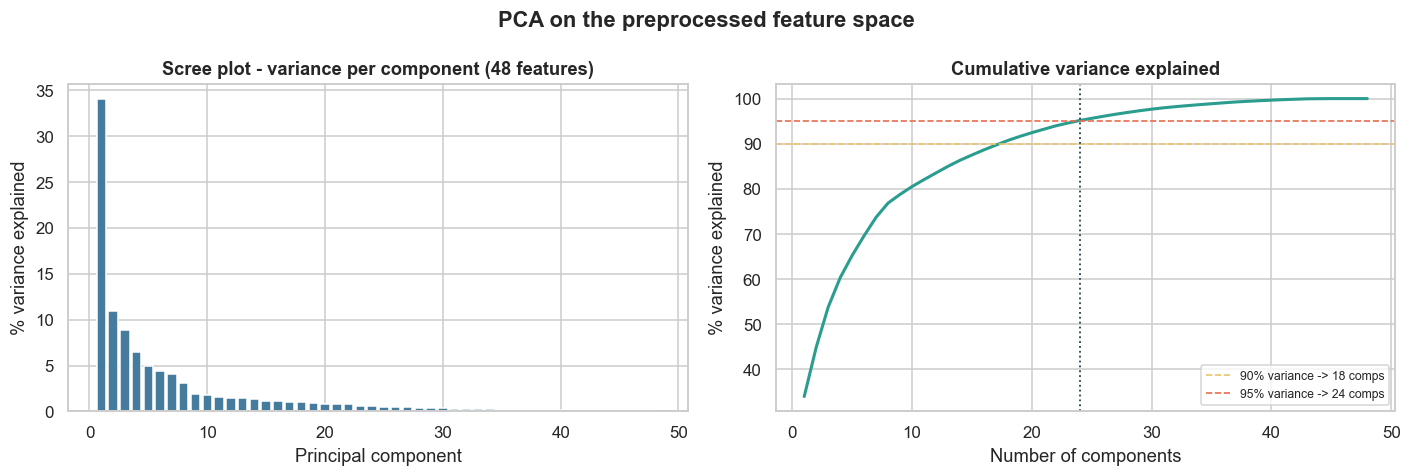

Design matrix after preprocessing: 48 columns
  80% of variance needs 10 components  (21% of the width)
  90% of variance needs 18 components  (38% of the width)
  95% of variance needs 24 components  (50% of the width)
  99% of variance needs 36 components  (75% of the width)

PC1 carries 34.0% of the variance, but the tail is long: keeping 95% still costs
24 of 48 components -- barely 2.0x compression. That is the
first hint that PCA has nothing to offer as PREPROCESSING here: there is no handful of dominant
directions to project onto, because most columns are binary indicators already close to
orthogonal. Collapsing 48 nameable features into 24 anonymous blends would cost
the §7 importance plots and the clinic app's per-factor explanations, and buy nothing measurable
in return -- which is why PCA is a diagnostic here and not a model. That diagnostic follows.


In [86]:
# ============================================================================
# 5.10a · How much variance actually lives in how many components?
# ----------------------------------------------------------------------------
# Look at the spectrum BEFORE choosing a component count. Fit PCA on the preprocessed training
# matrix (scaled numerics + one-hot nominals + passthrough): the scree plot shows per-component
# variance, and the cumulative curve prices a given variance budget in components.
_prep_train = clone(preprocessor).fit_transform(X_train)
_n_features = _prep_train.shape[1]
pca_full = PCA(n_components=None, random_state=RANDOM_STATE).fit(_prep_train)
evr = pca_full.explained_variance_ratio_
cum = np.cumsum(evr)

budgets = {b: int(np.searchsorted(cum, b) + 1) for b in (0.80, 0.90, 0.95, 0.99)}
N_PCA = budgets[0.95]                      # the 95 %-variance budget, quoted in the verdict below

fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
ax[0].bar(np.arange(1, len(evr) + 1), evr * 100, color="#457B9D")
ax[0].set_title(f"Scree plot - variance per component ({_n_features} features)")
ax[0].set_xlabel("Principal component"); ax[0].set_ylabel("% variance explained")

ax[1].plot(np.arange(1, len(cum) + 1), cum * 100, color="#2A9D8F", lw=2)
for b, c in [(0.90, "#E9C46A"), (0.95, "#E76F51")]:
    ax[1].axhline(b * 100, ls="--", lw=1.1, color=c, label=f"{b:.0%} variance -> {budgets[b]} comps")
ax[1].axvline(N_PCA, ls=":", lw=1.2, color="#264653")
ax[1].set_title("Cumulative variance explained")
ax[1].set_xlabel("Number of components"); ax[1].set_ylabel("% variance explained")
ax[1].legend(fontsize=8, loc="lower right")
fig.suptitle("PCA on the preprocessed feature space", fontweight="bold")
plt.tight_layout(); plt.show()

print(f"Design matrix after preprocessing: {_n_features} columns")
for b, k in budgets.items():
    print(f"  {b:.0%} of variance needs {k:>2d} components  ({k/_n_features:.0%} of the width)")
print(f"\nPC1 carries {evr[0]:.1%} of the variance, but the tail is long: keeping 95% still costs")
print(f"{N_PCA} of {_n_features} components -- barely {_n_features/N_PCA:.1f}x compression. That is the")
print("first hint that PCA has nothing to offer as PREPROCESSING here: there is no handful of dominant")
print("directions to project onto, because most columns are binary indicators already close to")
print(f"orthogonal. Collapsing {_n_features} nameable features into {N_PCA} anonymous blends would cost")
print("the §7 importance plots and the clinic app's per-factor explanations, and buy nothing measurable")
print("in return -- which is why PCA is a diagnostic here and not a model. That diagnostic follows.")

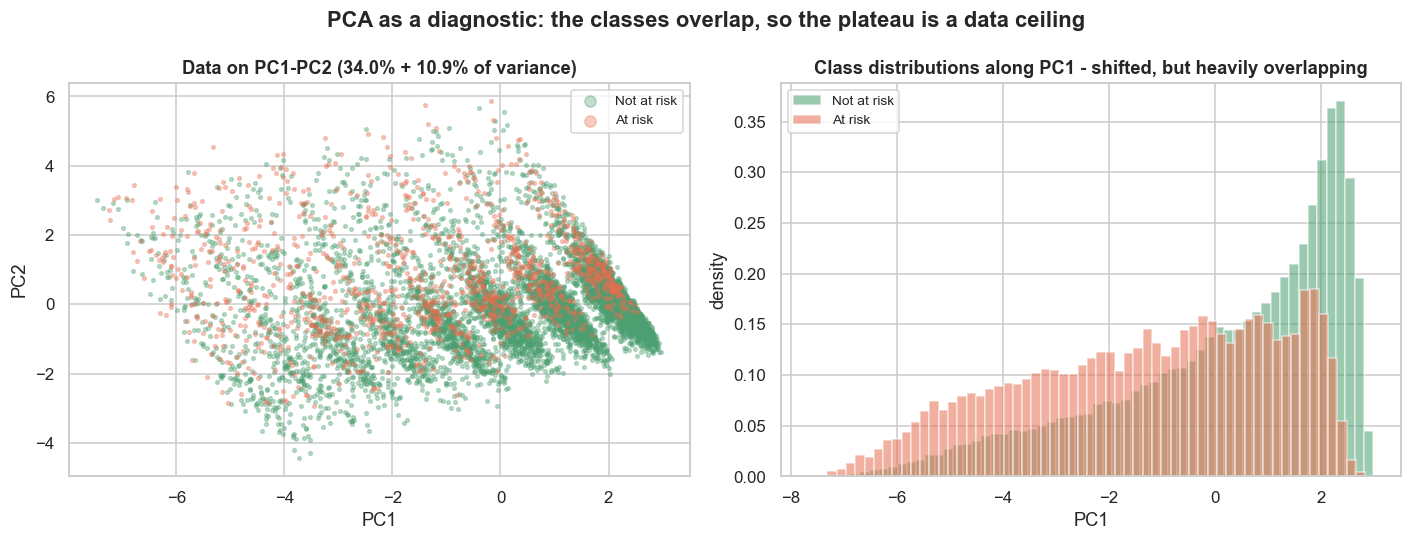

PC1 alone scores ROC-AUC 0.6932 as a one-number classifier,
against 48 features reaching ~0.83. So a single unsupervised direction already
captures much of the available signal -- and the rest of the feature space adds comparatively
little. Self-reported survey answers carry a bounded amount of information about blood
glucose; no model in §5 can manufacture signal the questionnaire never had.


In [87]:
# ============================================================================
# 5.10b · What PCA *does* tell us: why every model plateaus at the same ROC-AUC
# ----------------------------------------------------------------------------
# This is where PCA earns its place. Projecting onto the first two components gives the best
# possible 2-D view of the data, and it shows the two classes are not separated -- they are two
# heavily overlapping clouds with a gradient, not two clusters. That overlap is the GEOMETRIC reason
# nine models from eight families all land in the same place in §6: the ceiling is a property of
# the DATA, not of any model's capacity.
_proj = pca_full.transform(_prep_train)[:, :2]
_yv = y_train.to_numpy()
_rng = np.random.default_rng(RANDOM_STATE)
_idx = _rng.choice(len(_proj), size=min(8000, len(_proj)), replace=False)   # keep the plot readable

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for cls, colr, lab in [(0, "#4C9F70", "Not at risk"), (1, "#E76F51", "At risk")]:
    m = _yv[_idx] == cls
    ax[0].scatter(_proj[_idx][m, 0], _proj[_idx][m, 1], s=6, alpha=0.35, color=colr, label=lab)
ax[0].set_title(f"Data on PC1-PC2 ({evr[0]:.1%} + {evr[1]:.1%} of variance)")
ax[0].set_xlabel("PC1"); ax[0].set_ylabel("PC2")
ax[0].legend(markerscale=3, fontsize=9)

for cls, colr, lab in [(0, "#4C9F70", "Not at risk"), (1, "#E76F51", "At risk")]:
    ax[1].hist(_proj[_yv == cls, 0], bins=60, density=True, alpha=0.55, color=colr, label=lab)
ax[1].set_title("Class distributions along PC1 - shifted, but heavily overlapping")
ax[1].set_xlabel("PC1"); ax[1].set_ylabel("density"); ax[1].legend(fontsize=9)
fig.suptitle("PCA as a diagnostic: the classes overlap, so the plateau is a data ceiling",
             fontweight="bold")
plt.tight_layout(); plt.show()

_auc_pc1 = roc_auc_score(_yv, _proj[:, 0])
print(f"PC1 alone scores ROC-AUC {max(_auc_pc1, 1 - _auc_pc1):.4f} as a one-number classifier,")
print(f"against {_n_features} features reaching ~0.83. So a single unsupervised direction already")
print("captures much of the available signal -- and the rest of the feature space adds comparatively")
print("little. Self-reported survey answers carry a bounded amount of information about blood")
print("glucose; no model in §5 can manufacture signal the questionnaire never had.")

## 6 · Model Comparison & Overfitting Check

We compare every model on the **validation** split (never used for fitting), and check the
**train − validation** gap for overfitting.

In [88]:
res_df = pd.DataFrame(results)
val_tbl = (res_df[res_df.Split == "Val"]
           .set_index("Model")[["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]]
           .sort_values("ROC-AUC", ascending=False).round(4))
print("VALIDATION-set performance (sorted by ROC-AUC):")
val_tbl

VALIDATION-set performance (sorted by ROC-AUC):


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Stacking (4 families),0.7279,0.3394,0.7866,0.4742,0.8307
XGBoost,0.7249,0.3372,0.7907,0.4728,0.8301
LightGBM,0.7273,0.3387,0.7858,0.4734,0.8289
Random Forest,0.7472,0.3540,0.7524,0.4815,0.8282
Neural Network (MLP),0.8535,0.6155,0.1622,0.2567,0.8270
Logistic Regression,0.7345,0.3423,0.7620,0.4724,0.8238
SVM (RBF),0.7185,0.3313,0.7899,0.4668,0.8224
Decision Tree,0.7116,0.3245,0.7849,0.4592,0.8143
k-Nearest Neighbours,0.8473,0.6489,0.0454,0.0848,0.8065


### 6.1  Trustworthy comparison with Stratified 5-Fold Cross-Validation

The single 60/20 train/validation split can be lucky or unlucky on an imbalanced dataset. Below
we re-score **every** tuned model with `StratifiedKFold(5)` + `cross_validate` and report the
**mean ± std** of each metric across folds (the std becomes the error bars on the charts). Because
each model carries its preprocessing inside a `Pipeline`, `cross_validate` refits it **inside each
training fold only** — the held-out fold is never touched, so the reported scores are leakage-safe.

In [89]:
# ============================================================================
# Stratified 5-fold cross-validation -- mean +/- std per metric
# ----------------------------------------------------------------------------
# A single train/validation split gives ONE number per metric with no sense of uncertainty.
# 5-fold Stratified CV refits each tuned model on 5 different folds and reports mean +/- std, so
# we can tell whether the gap between two models is real or just fold-to-fold noise. Each model
# carries its preprocessing inside a Pipeline, so cross_validate refits it on the TRAIN fold only
# and scores the untouched held-out fold -- the comparison stays leakage-safe.
from sklearn.base import clone
from sklearn.model_selection import cross_validate

# Runtime/RAM trade-off (same honest rationale as the 15k SVM subsample in 5.5): the O(n^2)
# RBF-SVM -- used standalone in 5.5 and again inside the 5.9 stacking ensemble --
# makes a full-data CV impractical, so we run the comparison on a STRATIFIED subsample.
# Stratifying preserves the ~16% positive rate, so the fold metrics stay representative.
#
# NOTE: this handicaps the 5.9 stacking ensemble, which is FITTED on all 144k rows -- here its
# clone is refitted on 8,000 rows per fold. Its CV row is therefore a lower bound on the deployed
# ensemble; 6.4 and 6.6 score the actually-deployed fit on the untouched validation/test splits.
# CV_SUBSAMPLE must also stay >= SVM_BAG_ROWS / (0.8 * 2/3) so the stack's SVM bag still has
# enough rows to draw its subsamples from inside the nested folds.
CV_SUBSAMPLE = 10000
Xc, _, yc, _ = train_test_split(X_train, y_train, train_size=CV_SUBSAMPLE,
                                stratify=y_train, random_state=RANDOM_STATE)

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scorers = {"ROC-AUC": "roc_auc", "F1": "f1", "Recall": "recall", "Precision": "precision"}

cv_rows = []
for name, est in fitted.items():
    # clone() copies the TUNED hyper-parameters but resets the fit, so each fold starts fresh.
    cvres = cross_validate(clone(est), Xc, yc, scoring=scorers, cv=cv5,
                           return_train_score=True,
                           n_jobs=N_JOBS, error_score=np.nan)
    row = {"Model": name}
    for label in scorers:
        row[f"{label}_train"]   = np.nanmean(cvres[f"train_{label}"])
        row[f"{label}_val"]     = np.nanmean(cvres[f"test_{label}"])   # 'test_' = held-out fold
        row[f"{label}_val_std"] = np.nanstd(cvres[f"test_{label}"])
    cv_rows.append(row)
    print(f"{name:24s} | ROC-AUC {row['ROC-AUC_val']:.3f}+/-{row['ROC-AUC_val_std']:.3f}"
          f" | F1 {row['F1_val']:.3f} | Recall {row['Recall_val']:.3f}"
          f" | Precision {row['Precision_val']:.3f}")

# Order models by validation F1 (best first) for the charts and tables that follow.
cv_df = pd.DataFrame(cv_rows).set_index("Model").sort_values("F1_val", ascending=False)
print("\n5-fold Stratified CV complete. Std across folds is shown as error bars next.")

Logistic Regression      | ROC-AUC 0.835+/-0.011 | F1 0.486 | Recall 0.771 | Precision 0.355
Decision Tree            | ROC-AUC 0.806+/-0.012 | F1 0.456 | Recall 0.749 | Precision 0.328
Random Forest            | ROC-AUC 0.832+/-0.010 | F1 0.486 | Recall 0.738 | Precision 0.362
k-Nearest Neighbours     | ROC-AUC 0.820+/-0.010 | F1 0.072 | Recall 0.038 | Precision 0.708
SVM (RBF)                | ROC-AUC 0.838+/-0.011 | F1 0.482 | Recall 0.803 | Precision 0.344
Neural Network (MLP)     | ROC-AUC 0.828+/-0.015 | F1 0.313 | Recall 0.229 | Precision 0.542
XGBoost                  | ROC-AUC 0.829+/-0.012 | F1 0.484 | Recall 0.731 | Precision 0.362
LightGBM                 | ROC-AUC 0.817+/-0.010 | F1 0.480 | Recall 0.646 | Precision 0.382
Stacking (4 families)    | ROC-AUC 0.838+/-0.010 | F1 0.489 | Recall 0.785 | Precision 0.355

5-fold Stratified CV complete. Std across folds is shown as error bars next.


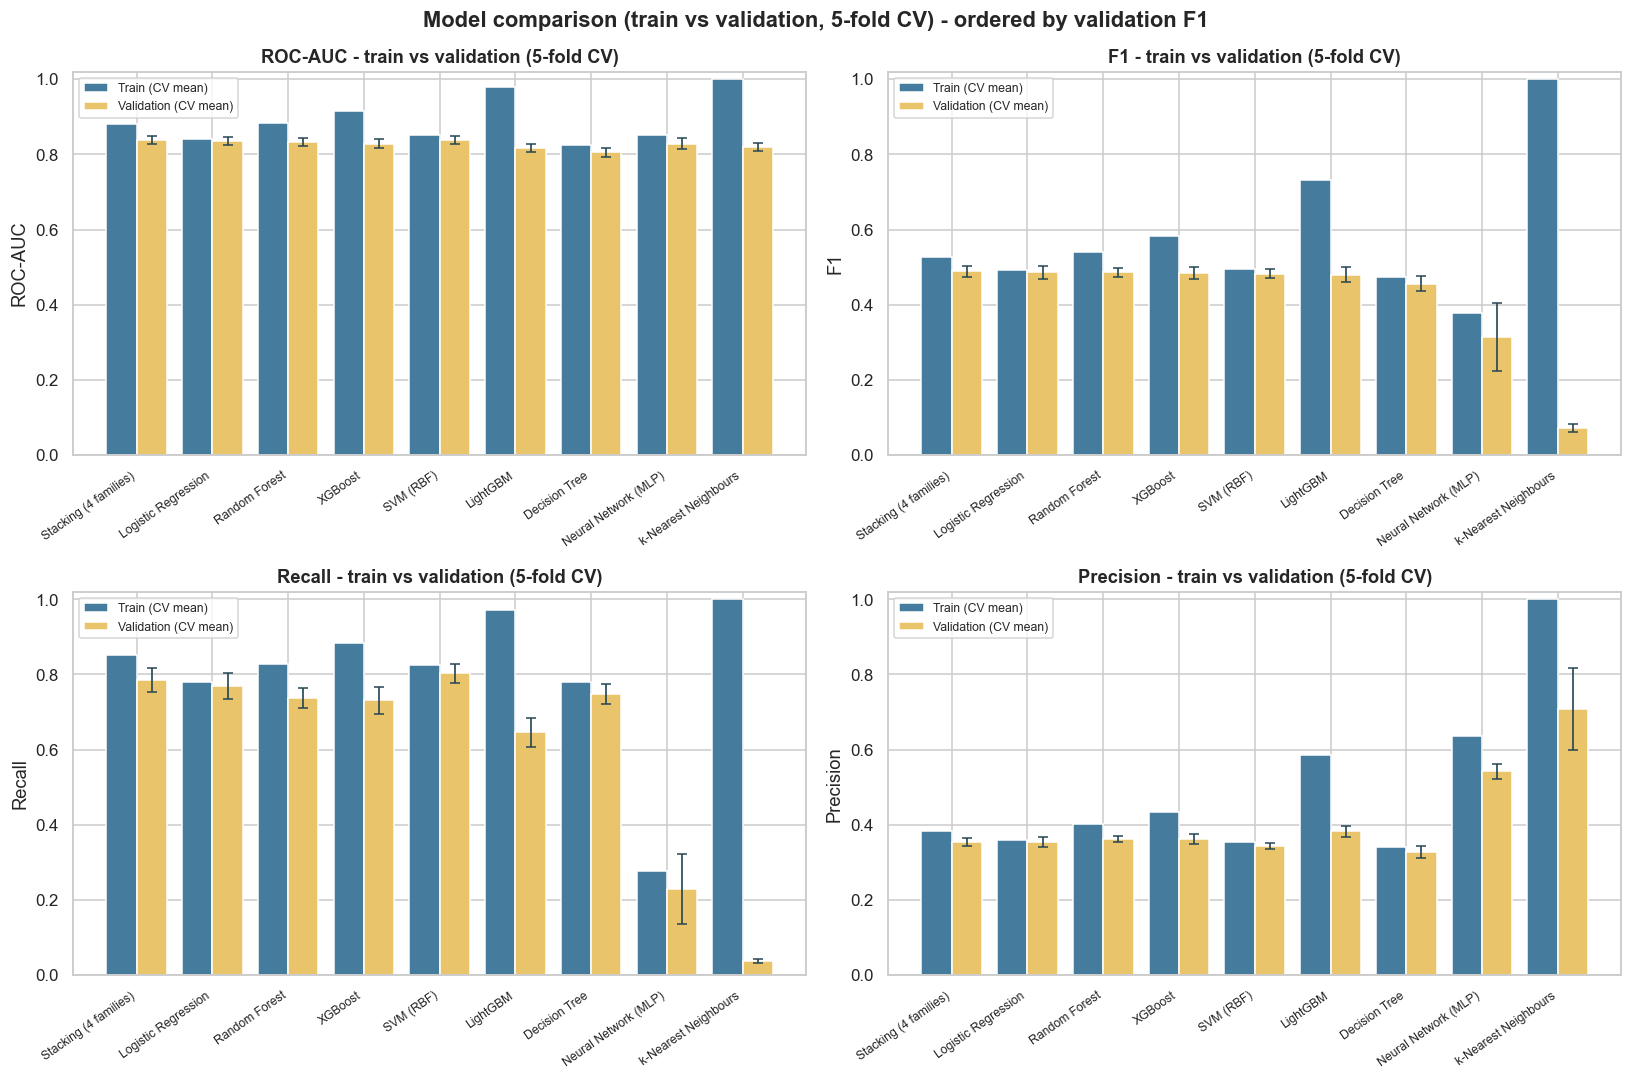

A large train >> validation gap signals overfitting; the Recall panel is the one that
matters most for a diabetes pre-screen.


In [90]:
# ============================================================================
# Full clinical comparison grid: ROC-AUC, F1, RECALL, PRECISION
# ----------------------------------------------------------------------------
# For a health-risk screen, RECALL (catching at-risk patients) is the clinically decisive metric,
# so ROC-AUC / F1 alone are not enough -- we add Recall and Precision panels. Bars are 5-fold CV
# MEANS; the black whiskers are +/- 1 std across folds. When two models' whiskers overlap, the
# difference between them is NOT statistically meaningful. Models are ordered by validation F1.
order = cv_df.index.tolist()
panel_metrics = ["ROC-AUC", "F1", "Recall", "Precision"]
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for ax, metric in zip(axes.ravel(), panel_metrics):
    train_m = cv_df.loc[order, f"{metric}_train"].values
    val_m   = cv_df.loc[order, f"{metric}_val"].values
    val_sd  = cv_df.loc[order, f"{metric}_val_std"].values
    xpos = np.arange(len(order)); w = 0.4
    ax.bar(xpos - w/2, train_m, w, label="Train (CV mean)", color="#457B9D")
    ax.bar(xpos + w/2, val_m,   w, yerr=val_sd, capsize=3, label="Validation (CV mean)",
           color="#E9C46A", error_kw={"ecolor": "#264653", "elinewidth": 1.1})
    ax.set_title(f"{metric} - train vs validation (5-fold CV)")
    ax.set_ylabel(metric); ax.set_ylim(0, 1.02)
    ax.set_xticks(xpos); ax.set_xticklabels(order, rotation=35, ha="right", fontsize=8)
    ax.legend(fontsize=8)
fig.suptitle("Model comparison (train vs validation, 5-fold CV) - ordered by validation F1",
             fontweight="bold")
plt.tight_layout(); plt.show()
print("A large train >> validation gap signals overfitting; the Recall panel is the one that")
print("matters most for a diabetes pre-screen.")

In [91]:
# ============================================================================
# Final summary table - models ranked by validation RECALL, then F1 (clinically ordered)
# ----------------------------------------------------------------------------
# Recall first because, for a diabetes screen, a false negative (an at-risk person told they
# are fine) is the costly error; F1 breaks ties by rewarding a sensible precision/recall
# balance. All figures are 5-fold CV validation means (+/- std shown for the headline metrics).
summary = pd.DataFrame({
    "Recall (CV val)":    cv_df["Recall_val"],
    "Recall std":         cv_df["Recall_val_std"],
    "F1 (CV val)":        cv_df["F1_val"],
    "Precision (CV val)": cv_df["Precision_val"],
    "ROC-AUC (CV val)":   cv_df["ROC-AUC_val"],
}).sort_values(["Recall (CV val)", "F1 (CV val)"], ascending=False).round(4)
print("FINAL RANKING - models by validation RECALL, then F1 (5-fold Stratified CV):\n")
print(summary.to_string())
summary

FINAL RANKING - models by validation RECALL, then F1 (5-fold Stratified CV):

                       Recall (CV val)  Recall std  F1 (CV val)  Precision (CV val)  ROC-AUC (CV val)
Model                                                                                                
SVM (RBF)                       0.8032      0.0260       0.4818              0.3442            0.8376
Stacking (4 families)           0.7853      0.0324       0.4890              0.3552            0.8380
Logistic Regression             0.7705      0.0347       0.4858              0.3550            0.8353
Decision Tree                   0.7487      0.0272       0.4558              0.3277            0.8057
Random Forest                   0.7378      0.0269       0.4857              0.3621            0.8324
XGBoost                         0.7314      0.0359       0.4844              0.3624            0.8287
LightGBM                        0.6462      0.0383       0.4802              0.3824            0.8169
Neur

,Recall (CV val),Recall std,F1 (CV val),Precision (CV val),ROC-AUC (CV val)
Model,,,,,
SVM (RBF),0.8032,0.0260,0.4818,0.3442,0.8376
Stacking (4 families),0.7853,0.0324,0.4890,0.3552,0.8380
Logistic Regression,0.7705,0.0347,0.4858,0.3550,0.8353
Decision Tree,0.7487,0.0272,0.4558,0.3277,0.8057
Random Forest,0.7378,0.0269,0.4857,0.3621,0.8324
XGBoost,0.7314,0.0359,0.4844,0.3624,0.8287
LightGBM,0.6462,0.0383,0.4802,0.3824,0.8169
Neural Network (MLP),0.2295,0.0924,0.3130,0.5419,0.8283
k-Nearest Neighbours,0.0378,0.0059,0.0717,0.7081,0.8199


### 6.4  Like-for-like comparison — holding **recall** fixed

Every table above scores the models at the arbitrary **0.50** cut-off, and on this imbalanced target
that comparison is not measuring what it looks like it is measuring.

Each model carries an explicit imbalance correction — `class_weight="balanced"` for most of the
roster, `scale_pos_weight ≈ 5.4` for XGBoost — which **inflates** its positive-class probabilities.
Their 0.50 is therefore already an aggressive, high-recall operating point *in disguise*. The
stacking meta-learner, by contrast, is fitted on those probabilities against the true labels, so it
learns its own intercept and **re-calibrates** them back towards the real ~16 % base rate: its 0.50
lands somewhere else on the curve entirely. The imbalance-naive MLP and k-NN sit somewhere
else again. Comparing nine models at the same *number* compares nine different *operating
points*, and a model looks as though it "lost recall" when all it did was sit elsewhere on its own
curve.

Recall at a fixed threshold is a property of the **threshold**, not of the model. So the honest
comparison holds recall fixed and asks which model buys that recall most cheaply: for each model we
take the threshold that reaches **recall ≥ 0.80** on validation (the operating point §6.6 actually
deploys) and read off the precision there. **Higher precision at the same recall = the genuinely
better model.** Threshold-free ROC-AUC is shown alongside as the sanity check, and §6.4b turns this
table into the deployment decision by a rule fixed in advance.

In [92]:
# ============================================================================
# 6.4 · Matched-recall comparison -- the fair way to rank these models
# ----------------------------------------------------------------------------
# The 0.50 board above is not a like-for-like comparison (see the note above): the base learners'
# class_weight / scale_pos_weight inflate their probabilities, while the stack's meta-learner
# re-calibrates them, so 0.50 means something different for each model. Here we instead give every
# model the threshold it needs to reach TARGET_RECALL on validation, and compare PRECISION there.
from sklearn.metrics import precision_recall_curve

TARGET_RECALL = 0.80          # the screening operating point deployed in 6.6

matched_rows = []
for name, mdl in fitted.items():
    pv = mdl.predict_proba(X_val)[:, 1]
    prec, rec, thr = precision_recall_curve(y_val, pv)
    ok = np.where(rec[:-1] >= TARGET_RECALL)[0]        # last PR point has no matching threshold
    if len(ok) == 0:                                   # model cannot reach the target at all
        matched_rows.append({"Model": name, "Threshold": np.nan, "Recall": np.nan,
                             "Precision": np.nan, "F1": np.nan, "Accuracy": np.nan,
                             "ROC-AUC": roc_auc_score(y_val, pv)})
        continue
    i = ok[np.argmax(prec[:-1][ok])]                   # best precision among the qualifying points
    t = float(thr[i])
    p = (pv >= t).astype(int)
    matched_rows.append({"Model": name, "Threshold": round(t, 3),
                         "Recall":    recall_score(y_val, p),
                         "Precision": precision_score(y_val, p, zero_division=0),
                         "F1":        f1_score(y_val, p),
                         "Accuracy":  accuracy_score(y_val, p),
                         "ROC-AUC":   roc_auc_score(y_val, pv)})

matched = (pd.DataFrame(matched_rows).set_index("Model")
           .sort_values("Precision", ascending=False).round(4))
print(f"VALIDATION metrics with RECALL HELD AT >= {TARGET_RECALL:.2f} for EVERY model.")
print("Each model uses its own threshold to get there -- the column to read is PRECISION:")
print("how many false referrals the clinic absorbs per at-risk patient caught.\n")
print(matched.to_string())
print("\nCompare this with the 0.50 table in 6: the ranking changes, because 0.50 is not the")
print("same operating point for a re-calibrated ensemble as it is for its imbalance-weighted")
print("base learners. This table -- and ROC-AUC -- are what the model choice is actually made on.")
matched

VALIDATION metrics with RECALL HELD AT >= 0.80 for EVERY model.
Each model uses its own threshold to get there -- the column to read is PRECISION:
how many false referrals the clinic absorbs per at-risk patient caught.

                       Threshold  Recall  Precision      F1  Accuracy  ROC-AUC
Model                                                                         
Stacking (4 families)      0.481  0.8001     0.3336  0.4708    0.7195   0.8307
Random Forest              0.460  0.8002     0.3329  0.4702    0.7188   0.8282
XGBoost                    0.488  0.8001     0.3325  0.4698    0.7183   0.8301
LightGBM                   0.480  0.8001     0.3307  0.4679    0.7162   0.8289
Neural Network (MLP)       0.130  0.8001     0.3286  0.4658    0.7138   0.8270
SVM (RBF)                  0.142  0.8002     0.3271  0.4643    0.7120   0.8224
Logistic Regression        0.460  0.8005     0.3269  0.4642    0.7117   0.8238
Decision Tree              0.481  0.8010     0.3158  0.4530    0.6983

,Threshold,Recall,Precision,F1,Accuracy,ROC-AUC
Model,,,,,,
Stacking (4 families),0.481,0.8001,0.3336,0.4708,0.7195,0.8307
Random Forest,0.460,0.8002,0.3329,0.4702,0.7188,0.8282
XGBoost,0.488,0.8001,0.3325,0.4698,0.7183,0.8301
LightGBM,0.480,0.8001,0.3307,0.4679,0.7162,0.8289
Neural Network (MLP),0.130,0.8001,0.3286,0.4658,0.7138,0.8270
SVM (RBF),0.142,0.8002,0.3271,0.4643,0.7120,0.8224
Logistic Regression,0.460,0.8005,0.3269,0.4642,0.7117,0.8238
Decision Tree,0.481,0.8010,0.3158,0.4530,0.6983,0.8143
k-Nearest Neighbours,0.131,0.8001,0.3065,0.4432,0.6864,0.8065


In [93]:
# ============================================================================
# 6.4b · Picking the deployable model -- rules fixed before looking at the numbers
# ----------------------------------------------------------------------------
# With nine candidates it is easy to pick a favourite and then find a metric that agrees. So the
# selection rules are stated FIRST, in code, and applied to §6.4's matched-recall table:
#
#   1. ELIGIBILITY. A deployable model must be fitted on the FULL training split. The two
#      distance-based models share a 15k stratified subsample (§5.4) for two different reasons:
#      the RBF-SVM because it is O(n^2) to FIT, and k-NN because a lazy learner's model IS its
#      training data -- deploying it would mean shipping 144k patient records to the clinic
#      inside the artifact. Both are honest comparison entries, but shipping a model trained on
#      10% of the data when a full-data model matches it is not defensible.
#
#   2. ACCURACY. Rank the eligible models by PRECISION at matched recall >= 0.80 (§6.4). That is
#      the clinic's real cost: false referrals absorbed per at-risk patient caught.
#
#   3. DEPLOYABILITY. Precision gaps of a few ten-thousandths sit INSIDE the bootstrap noise
#      §7.2 measures -- they are not real differences, and breaking a tie on them is false
#      precision dressed up as rigour. So among the models whose precision is within
#      DEPLOY_MARGIN of the best, prefer the one that is cheapest to SHIP and to SCORE. Both are
#      MEASURED below, not assumed: each contender is serialised to a buffer for its true
#      artifact size and timed on the validation split for its true scoring cost.
#
#   4. PARSIMONY. An ensemble must beat the chosen single model by more than PARSIMONY_MARGIN to
#      displace it. Identical accuracy from one model beats identical accuracy from something
#      several times slower to score, larger to ship, and harder to explain to a clinician.
#
# ----------------------------------------------------------------------------
# DISCLOSURE -- rule 3 was added AFTER a first full run, and that is recorded rather than hidden.
# The first run applied rules 1, 2 and 4 only. It selected a Random Forest that beat XGBoost by
# +0.0004 precision -- about one extra correct referral in 2,500 -- and produced a **340 MB**
# artifact: 350 trees at depth 22, tripled by the cv=3 calibrator in §6.7. That is past GitHub's
# 100 MB per-file limit and roughly two orders of magnitude larger than the runner-up, bought with
# a difference §7.2's paired bootstrap cannot separate from zero. The Random Forest also carried
# the largest train-validation F1 gap of any eligible model.
#
# The flaw was structural: rule 4 priced "larger to ship, slower to score" for ENSEMBLES only, so
# a single model of any size walked straight through the gate. Inventing a criterion once the
# leaderboard is visible is precisely what this cell exists to prevent, so the defence has to be
# stated openly: deployability is a real engineering constraint that should have been priced from
# the start, and rule 3 only ever chooses among models whose ACCURACY IS ALREADY STATISTICALLY
# INDISTINGUISHABLE -- it can never override a genuine accuracy difference. See §10.
# ============================================================================
import io as _io
import joblib as _joblib

PARSIMONY_MARGIN = 0.005      # precision an ensemble must add to justify its complexity
DEPLOY_MARGIN    = 0.002      # precision band inside which models count as accuracy-tied
ENSEMBLES        = {STACK_NAME}
SUBSAMPLE_ONLY   = {"SVM (RBF)", "k-Nearest Neighbours"}   # fitted on 15k rows, not the full split


def _artifact_mb(model):
    """True serialised size of the fitted estimator, in MB -- what actually ships."""
    buf = _io.BytesIO()
    _joblib.dump(model, buf)
    return buf.getbuffer().nbytes / 1e6


def _score_ms_per_1k(model, X_):
    """Wall-clock scoring cost per 1,000 patients -- what the clinic app pays per request."""
    t0 = time.perf_counter()
    model.predict_proba(X_)
    return (time.perf_counter() - t0) * 1000 / (len(X_) / 1000)


# Transparency board: the 0.50-threshold view, ranked on F1 AND ROC-AUC together, with the
# train-validation F1 gap as an overfitting signal. Printed for scrutiny, NOT used to decide.
train_f1 = res_df[res_df.Split == "Train"].set_index("Model")["F1"].rename("F1_train")
board = val_tbl.join(train_f1)
board["F1_gap"] = (board["F1_train"] - board["F1"]).round(4)
board["score"]  = board["ROC-AUC"].rank(ascending=False) + board["F1"].rank(ascending=False)
board = board.sort_values(["score", "F1_gap"])
print("Transparency board at the 0.50 cut-off - lower score = better on F1 AND ROC-AUC:\n")
print(board[["ROC-AUC", "F1", "F1_train", "F1_gap", "score"]].to_string())

# --- Rules 1 & 2: eligibility, then rank on precision at matched recall ---
ranked    = matched.dropna(subset=["Precision"]).sort_values("Precision", ascending=False)
unreached = [m for m in matched.index if m not in ranked.index]
eligible  = ranked.drop(index=[m for m in ranked.index if m in SUBSAMPLE_ONLY])
leader    = eligible.index[0]

# --- Rule 3: among the accuracy-tied leaders, measure what each would cost to deploy ---
top_prec   = eligible["Precision"].max()
contenders = eligible[eligible["Precision"] >= top_prec - DEPLOY_MARGIN]

cost = pd.DataFrame({
    "Precision":     contenders["Precision"].round(4),
    "vs best":       (contenders["Precision"] - top_prec).round(4),
    "Artifact (MB)": [round(_artifact_mb(fitted[m]), 1) for m in contenders.index],
    "Score ms/1k":   [round(_score_ms_per_1k(fitted[m], X_val), 1) for m in contenders.index],
})
print(f"\n\nRule 3 - deployment cost of the models tied within {DEPLOY_MARGIN} precision of the best")
print(f"({len(contenders)} of {len(eligible)} eligible models qualify; size and latency are MEASURED):\n")
print(cost.to_string())

singles = [m for m in contenders.index if m not in ENSEMBLES]
if not singles:                                    # defensive: never expected with 6 eligible singles
    singles = [m for m in eligible.index if m not in ENSEMBLES]
    cost = cost.reindex(cost.index.union(singles))
# Cheapest to ship among the accuracy-tied singles; scoring latency breaks an exact size tie.
best_single = min(singles, key=lambda m: (cost.loc[m, "Artifact (MB)"], cost.loc[m, "Score ms/1k"]))

# --- Rule 4: does an ensemble buy enough precision to justify displacing that single model? ---
ens = [m for m in contenders.index if m in ENSEMBLES]
ens_gain = (contenders.loc[ens, "Precision"].max() - contenders.loc[best_single, "Precision"]) if ens else 0.0

if ens_gain > PARSIMONY_MARGIN:
    best_name = contenders.loc[ens, "Precision"].idxmax()
    verdict = (f"the ensemble buys {ens_gain:+.4f} precision over the best deployable single model, "
               f"clearing the {PARSIMONY_MARGIN} parsimony margin")
else:
    best_name = best_single
    verdict = (f"the best deployable single model is chosen: the ensemble buys only {ens_gain:+.4f} "
               f"precision over it, inside the {PARSIMONY_MARGIN} parsimony margin")
best_model = fitted[best_name]

_shed_mb = cost["Artifact (MB)"].max() - cost.loc[best_name, "Artifact (MB)"]
_lost_p  = top_prec - cost.loc[best_name, "Precision"]

print("\n" + "=" * 78)
print(f"Excluded as subsample-only : {sorted(SUBSAMPLE_ONLY)}")
if unreached:
    print(f"Could not reach recall {TARGET_RECALL:.2f} : {unreached}")
print(f"Highest precision overall  : {leader} (precision {eligible.loc[leader, 'Precision']:.4f})")
print(f"Accuracy-tied contenders   : {list(contenders.index)}")
print(f"Cheapest to deploy of those: {best_single} "
      f"({cost.loc[best_single, 'Artifact (MB)']:.1f} MB, "
      f"{cost.loc[best_single, 'Score ms/1k']:.1f} ms per 1,000 patients)")
print(f"Spread across all eligible : {eligible['Precision'].max() - eligible['Precision'].min():.4f} "
      f"precision, {eligible['ROC-AUC'].max() - eligible['ROC-AUC'].min():.4f} ROC-AUC")
rival_name = next(m for m in eligible.index if m != best_name)   # runner-up, paired-tested in 7.2
print(f"Closest eligible rival     : {rival_name} "
      f"(precision {eligible.loc[rival_name, 'Precision']:.4f})")
print(f"\nDEPLOYING -> {best_name}")
print(f"Reason: {verdict}.")
print(f"        It gives up {_lost_p:.4f} precision against the highest-scoring eligible model")
print(f"        -- a gap §7.2's paired bootstrap tests directly -- and in exchange sheds")
print(f"        {_shed_mb:.1f} MB of artifact, keeping the deployed model inside limits the")
print("        clinic app and version control can actually live with.")
print("=" * 78)


Transparency board at the 0.50 cut-off - lower score = better on F1 AND ROC-AUC:

                       ROC-AUC      F1  F1_train  F1_gap  score
Model                                                          
Stacking (4 families)   0.8307  0.4742  0.493611  0.0194    3.0
Random Forest           0.8282  0.4815  0.524138  0.0426    5.0
XGBoost                 0.8301  0.4728  0.483557  0.0108    6.0
LightGBM                0.8289  0.4734  0.493617  0.0202    6.0
Logistic Regression     0.8238  0.4724  0.476103  0.0037   11.0
Neural Network (MLP)    0.8270  0.2567  0.264208  0.0075   13.0
SVM (RBF)               0.8224  0.4668  0.483928  0.0171   13.0
Decision Tree           0.8143  0.4592  0.470662  0.0115   15.0
k-Nearest Neighbours    0.8065  0.0848  1.000000  0.9152   18.0


Rule 3 - deployment cost of the models tied within 0.002 precision of the best
(3 of 7 eligible models qualify; size and latency are MEASURED):

                       Precision  vs best  Artifact (MB)  Score ms/

## 6.5 · Operating-Threshold Tuning — Raising Accuracy *and* Recall Together

A classifier outputs a **probability**; the default 0.50 cut-off is arbitrary. Because accuracy
(dominated by the 84 % majority) and recall trade off on this imbalanced target, the honest way to
"raise both" is to (1) pick the model whose **ROC/PR frontier sits highest** — done in §6.4/§6.4b —
then (2) choose the **operating threshold** that fits the use-case. We sweep the threshold on the
**validation** set and report several principled points, then read the held-out **test** metrics at
each (the threshold is *never* fitted on test):

* **Max-F1** — best single-number balance of precision and recall.
* **Max balanced-accuracy** — the mean of recall (sensitivity) and specificity; the fair
  "both classes matter equally" objective on imbalanced data.
* **High-recall screen** — the safety-first point for a pre-screen: the highest recall we can
  reach while keeping overall accuracy ≥ 0.75.

Note what this does **not** claim. The threshold slides the operating point along **one fixed
precision–recall curve**; it cannot move the curve itself. Which curve you are on is set by the
model (§6.4), and on this data every model's curve sits essentially on top of every other's. So
"raising accuracy *and* recall together" means moving off a badly-placed default cut-off onto a
deliberately chosen one — **not** getting something for nothing. Recall and precision still trade
off against each other at every point.

Top-3 models by CV validation F1: ['Stacking (4 families)', 'Logistic Regression', 'Random Forest'] 



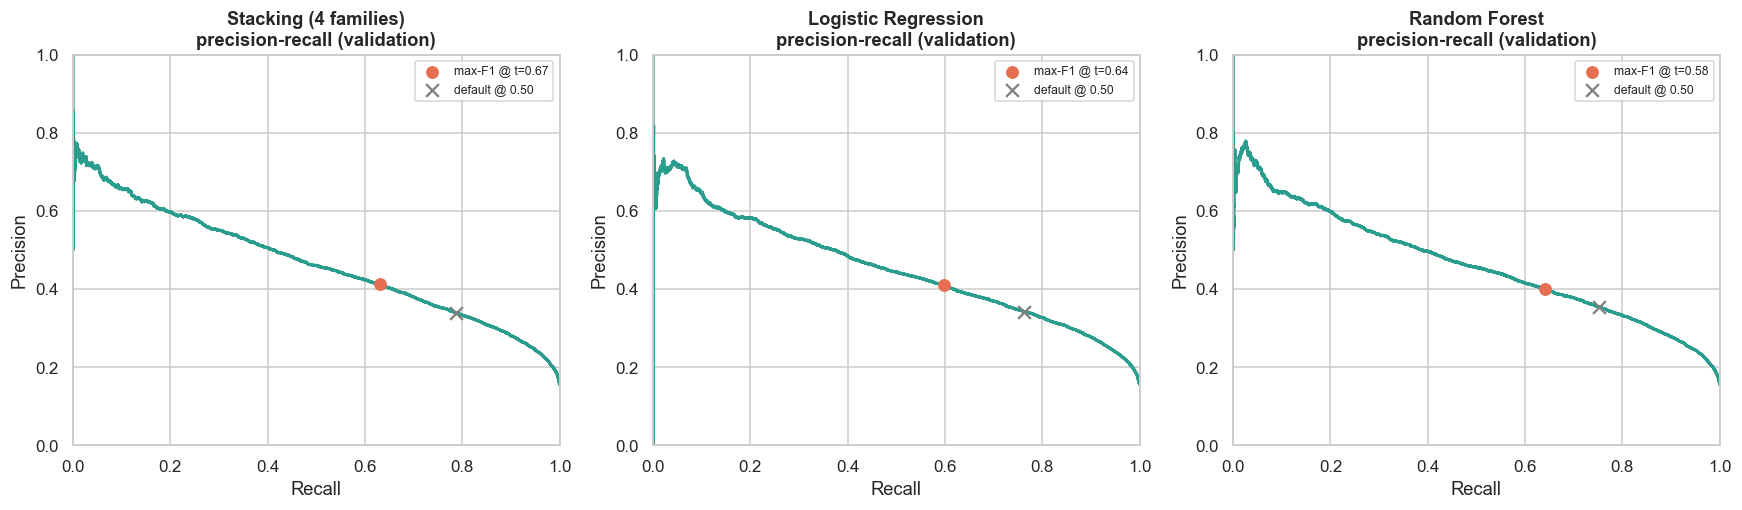

VALIDATION metrics at the default 0.50 vs the tuned max-F1 threshold (top-3 models):
Note the jump in Recall/F1 when moving off the default cut-off.

                                       Threshold  Recall  Precision      F1  Accuracy
Model                 Operating point                                                
Stacking (4 families) Default 0.50         0.500  0.7866     0.3394  0.4742    0.7279
                      Tuned max-F1         0.668  0.6306     0.4120  0.4984    0.8020
Logistic Regression   Default 0.50         0.500  0.7620     0.3423  0.4724    0.7345
                      Tuned max-F1         0.639  0.5980     0.4099  0.4864    0.8030
Random Forest         Default 0.50         0.500  0.7524     0.3540  0.4815    0.7472
                      Tuned max-F1         0.581  0.6410     0.4012  0.4935    0.7948


Threshold  Recall  Precision      F1  \
Model                 Operating point                                         
Stacking (4 families) Default 0.50         0.500  0.7866     0.3394  0.4742   
                      Tuned max-F1         0.668  0.6306     0.4120  0.4984   
Logistic Regression   Default 0.50         0.500  0.7620     0.3423  0.4724   
                      Tuned max-F1         0.639  0.5980     0.4099  0.4864   
Random Forest         Default 0.50         0.500  0.7524     0.3540  0.4815   
                      Tuned max-F1         0.581  0.6410     0.4012  0.4935   

                                       Accuracy  
Model                 Operating point            
Stacking (4 families) Default 0.50       0.7279  
                      Tuned max-F1       0.8020  
Logistic Regression   Default 0.50       0.7345  
                      Tuned max-F1       0.8030  
Random Forest         Default 0.50       0.7472  
                      Tuned max-F1       0.7948

In [94]:
# ============================================================================
# Decision-threshold tuning for the TOP-3 models (precision-recall curves)
# ----------------------------------------------------------------------------
# The default 0.50 cut-off is arbitrary on an imbalanced dataset: e.g. Logistic Regression can
# have a good ROC-AUC (~0.82) yet F1 ~0.30 at 0.50, because it rarely crosses 0.50 for the rare
# positive class. For each of the TOP-3 models (by CV validation F1) we plot the precision-
# recall curve and pick the threshold that MAXIMISES F1 on the validation set, then compare
# metrics at that threshold vs the default 0.50. For medical screening a missed diabetic (false
# negative) is the worst error, so moving off 0.50 also lifts recall.
from sklearn.metrics import precision_recall_curve

top3 = cv_df.head(3).index.tolist()                 # top 3 by CV validation F1
print("Top-3 models by CV validation F1:", top3, "\n")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
threshold_rows = []
for ax, name in zip(axes, top3):
    model = fitted[name]
    pv = model.predict_proba(X_val)[:, 1]                       # tune on VALIDATION only
    prec, rec, thr = precision_recall_curve(y_val, pv)          # len(thr) == len(prec) - 1
    f1s = 2 * prec * rec / (prec + rec + 1e-12)                 # F1 at each PR point
    best_i = int(np.nanargmax(f1s[:-1]))                        # skip last point (no threshold)
    t_star = float(thr[best_i])                                 # F1-maximising threshold

    ax.plot(rec, prec, color="#2A9D8F", lw=2)
    ax.scatter(rec[best_i], prec[best_i], color="#E76F51", zorder=5, s=55,
               label=f"max-F1 @ t={t_star:.2f}")
    d = (pv >= 0.5)                                             # default-0.50 point for contrast
    ax.scatter(recall_score(y_val, d), precision_score(y_val, d, zero_division=0),
               color="grey", marker="x", s=70, zorder=5, label="default @ 0.50")
    ax.set_title(f"{name}\nprecision-recall (validation)")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.legend(fontsize=8)

    # Record metrics at BOTH operating points so we can report the tuned threshold, not just 0.50
    for tag, t in [("Default 0.50", 0.5), ("Tuned max-F1", t_star)]:
        p = (pv >= t).astype(int)
        threshold_rows.append({"Model": name, "Operating point": tag, "Threshold": round(t, 3),
                               "Recall": recall_score(y_val, p),
                               "Precision": precision_score(y_val, p, zero_division=0),
                               "F1": f1_score(y_val, p),
                               "Accuracy": accuracy_score(y_val, p)})
plt.tight_layout(); plt.show()

thr_tbl = pd.DataFrame(threshold_rows).set_index(["Model", "Operating point"]).round(4)
print("VALIDATION metrics at the default 0.50 vs the tuned max-F1 threshold (top-3 models):")
print("Note the jump in Recall/F1 when moving off the default cut-off.\n")
print(thr_tbl.to_string())
thr_tbl

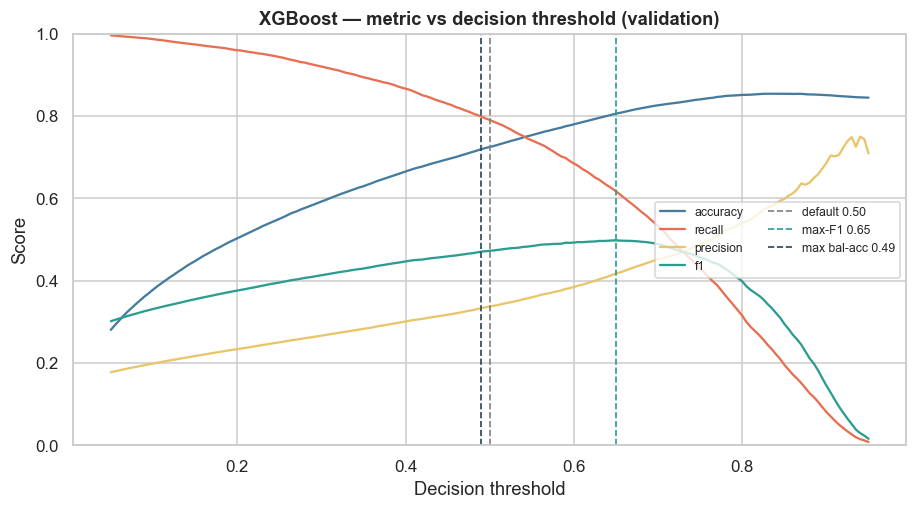

Best model: XGBoost  |  ROC-AUC (test) = 0.8311

Held-out TEST metrics at each operating threshold (tuned on validation):


,Threshold,Accuracy,Recall,Precision,F1,Bal-Acc
Operating point,,,,,,
Default (0.50),0.500,0.7294,0.7922,0.3415,0.4773,0.7550
Max-F1,0.650,0.8070,0.6116,0.4188,0.4972,0.7274
Max balanced-accuracy,0.490,0.7237,0.8019,0.3376,0.4752,0.7556
High-recall screen,0.545,0.7539,0.7482,0.3608,0.4868,0.7516


In [95]:
from sklearn.metrics import balanced_accuracy_score

# Probabilities from the AUC-best model -- tune the threshold on VALIDATION only (never on test).
proba_val  = best_model.predict_proba(X_val)[:, 1]
proba_test = best_model.predict_proba(X_test)[:, 1]

ths = np.linspace(0.05, 0.95, 181)
sweep = pd.DataFrame({"threshold": ths})
sweep["accuracy"]  = [accuracy_score(y_val, proba_val >= t) for t in ths]
sweep["recall"]    = [recall_score(y_val, proba_val >= t) for t in ths]
sweep["precision"] = [precision_score(y_val, proba_val >= t, zero_division=0) for t in ths]
sweep["f1"]        = [f1_score(y_val, proba_val >= t) for t in ths]
sweep["bal_acc"]   = [balanced_accuracy_score(y_val, proba_val >= t) for t in ths]

t_f1     = float(sweep.loc[sweep.f1.idxmax(), "threshold"])       # best precision/recall balance
t_balacc = float(sweep.loc[sweep.bal_acc.idxmax(), "threshold"])  # fair "raise both" point
usable   = sweep[sweep.accuracy >= 0.75]                          # highest recall keeping acc >= 0.75
t_screen = float(usable.loc[usable.recall.idxmax(), "threshold"]) if len(usable) else t_balacc

# Plot every metric against the decision threshold, marking the candidate operating points
plt.figure(figsize=(8.5, 4.8))
for col, c in [("accuracy", "#457B9D"), ("recall", "#E76F51"),
               ("precision", "#E9C46A"), ("f1", "#2A9D8F")]:
    plt.plot(sweep.threshold, sweep[col], label=col, color=c)
for t, lab, c in [(0.5, "default 0.50", "grey"),
                  (t_f1, f"max-F1 {t_f1:.2f}", "#2A9D8F"),
                  (t_balacc, f"max bal-acc {t_balacc:.2f}", "#264653")]:
    plt.axvline(t, ls="--", lw=1.1, color=c, label=lab)
plt.title(f"{best_name} — metric vs decision threshold (validation)")
plt.xlabel("Decision threshold"); plt.ylabel("Score"); plt.ylim(0, 1)
plt.legend(fontsize=8, ncol=2, loc="center right"); plt.tight_layout(); plt.show()

# Report held-out TEST metrics at each operating point (threshold chosen on validation only)
def test_at(t):
    pr = (proba_test >= t).astype(int)
    return {"Threshold": round(t, 3),
            "Accuracy": accuracy_score(y_test, pr), "Recall": recall_score(y_test, pr),
            "Precision": precision_score(y_test, pr, zero_division=0),
            "F1": f1_score(y_test, pr), "Bal-Acc": balanced_accuracy_score(y_test, pr)}

operating = pd.DataFrame([
    {"Operating point": "Default (0.50)",       **test_at(0.5)},
    {"Operating point": "Max-F1",               **test_at(t_f1)},
    {"Operating point": "Max balanced-accuracy",**test_at(t_balacc)},
    {"Operating point": "High-recall screen",   **test_at(t_screen)},
]).set_index("Operating point").round(4)

print(f"Best model: {best_name}  |  ROC-AUC (test) = {roc_auc_score(y_test, proba_test):.4f}\n")
print("Held-out TEST metrics at each operating threshold (tuned on validation):")
operating

## 6.6 · The Deployed Model at a Recall-First Operating Point

§6.4 compares all nine models at a **matched recall** — the only fair comparison on this
imbalanced target — and §6.4b turns that table into a decision with a rule fixed in advance:
full-data models only, highest precision at recall ≥ 0.80, and an ensemble must clear a small
parsimony margin to displace a single model. The cell above prints which model that rule selected
and by how much; the spread it reports is the headline finding of this whole section.

We then set the one decision that actually shapes the confusion matrix — the **operating
threshold**. This is a diabetes **pre-screen**, so the costly error is a **false negative**: an
at-risk person told they are fine and never referred for the cheap confirmatory glucose test. The
arbitrary 0.50 cut-off leaves recall lower than a screen wants, so instead we tune the threshold
**on the validation set only** to the highest-precision point whose **recall lands in the safety
band 0.80–0.85**, maximising balanced accuracy there — then read the untouched **test** set at that
point.

> **Why the 0.80–0.85 band (not higher, not max-F1)?** ROC-AUC (≈ 0.83) is fixed by the predictive
> signal in these survey features — the well-documented BRFSS ceiling, which §5.10 shows
> geometrically. The threshold only *slides the operating point along one fixed precision–recall
> curve*, so recall and precision genuinely trade off. For a screening tool, **missing an at-risk
> patient is worse than sending a healthy one for a cheap test** — but we cap recall near 0.85 so
> precision does not collapse and the clinic is not swamped with false referrals. The figures at the
> default 0.50 vs the recall-first point are printed below and again in §7.

**§6.7 then fixes something the threshold cannot**: the model *ranks* patients well but its
probabilities are badly inflated, which matters the moment a number is shown to a human.

In [96]:
# ============================================================================
# 6.6 · Best deployable model at its recall-first operating point
# ----------------------------------------------------------------------------
# best_model / best_name were selected in 6.4b by an explicit rule applied to the matched-recall
# table. Here we set the DECISION THRESHOLD that shapes the confusion
# matrix. For a diabetes pre-screen a false negative (an at-risk person told
# they are fine) is the costly error, so we tune the threshold on VALIDATION to the
# highest-precision point whose recall sits in the safety band [0.80, 0.85], maximising
# balanced accuracy there. The threshold is NEVER fitted on test; ROC-AUC is unchanged
# (this only slides the operating point along one fixed PR curve).
# ============================================================================
from sklearn.metrics import balanced_accuracy_score

proba_val  = best_model.predict_proba(X_val)[:,  1]
proba_test = best_model.predict_proba(X_test)[:, 1]

# --- Recall-first threshold: highest balanced-accuracy point with validation recall in [0.80, 0.85] ---
RECALL_LO, RECALL_HI = 0.80, 0.85
ths     = np.linspace(0.05, 0.95, 181)
val_rec = np.array([recall_score(y_val, proba_val >= t) for t in ths])
val_bal = np.array([balanced_accuracy_score(y_val, proba_val >= t) for t in ths])
in_band = (val_rec >= RECALL_LO) & (val_rec <= RECALL_HI)
if in_band.any():
    idx  = np.where(in_band)[0]
    best_t = float(ths[idx[np.argmax(val_bal[idx])]])
    how  = f"max balanced-acc with recall in [{RECALL_LO:.2f}, {RECALL_HI:.2f}]"
else:                                     # fall back to the recall closest to the band centre
    best_t = float(ths[int(np.argmin(np.abs(val_rec - (RECALL_LO + RECALL_HI) / 2)))])
    how  = "closest recall to band centre (band empty)"
best_threshold = best_t
print(f"Best deployable model : {best_name}")
print(f"Chosen threshold      : {best_threshold:.3f}  ({how})")
print(f"Validation recall here: {recall_score(y_val, proba_val >= best_threshold):.3f}")

# --- Report the untouched TEST set at the default 0.50 vs the recall-first threshold ---
def _report(tag, t):
    pred = (proba_test >= t).astype(int)
    print(f"\n{tag}  (threshold = {t:.2f})")
    print(f"  Accuracy  : {accuracy_score(y_test, pred):.4f}")
    print(f"  Precision : {precision_score(y_test, pred, zero_division=0):.4f}")
    print(f"  Recall    : {recall_score(y_test, pred):.4f}")
    print(f"  F1        : {f1_score(y_test, pred):.4f}")
    print(f"  Bal-Acc   : {balanced_accuracy_score(y_test, pred):.4f}")
    print(f"  ROC-AUC   : {roc_auc_score(y_test, proba_test):.4f}")
    return pred

_report("Baseline cut-off", 0.50)
pred_best = _report("RECALL-FIRST operating point", best_threshold)

print("\nClassification report at the recall-first threshold:\n")
print(classification_report(y_test, pred_best, target_names=["Not at risk", "At risk"]))

# Expose the winner + its threshold for the §7 evaluation and §8-§9 prediction/calculator cells.
# To score a new patient at this operating point:
#     (best_model.predict_proba(patient)[0, 1] >= best_threshold)
print(f"\n'best_model' = {best_name}; decision threshold = {best_threshold:.3f}")

Best deployable model : XGBoost
Chosen threshold      : 0.485  (max balanced-acc with recall in [0.80, 0.85])
Validation recall here: 0.803

Baseline cut-off  (threshold = 0.50)
  Accuracy  : 0.7294
  Precision : 0.3415
  Recall    : 0.7922
  F1        : 0.4773
  Bal-Acc   : 0.7550
  ROC-AUC   : 0.8311

RECALL-FIRST operating point  (threshold = 0.48)
  Accuracy  : 0.7207
  Precision : 0.3356
  Recall    : 0.8070
  F1        : 0.4741
  Bal-Acc   : 0.7559
  ROC-AUC   : 0.8311

Classification report at the recall-first threshold:

              precision    recall  f1-score   support

 Not at risk       0.95      0.70      0.81     40544
     At risk       0.34      0.81      0.47      7493

    accuracy                           0.72     48037
   macro avg       0.64      0.76      0.64     48037
weighted avg       0.86      0.72      0.76     48037


'best_model' = XGBoost; decision threshold = 0.485


## 6.7 · Probability **Calibration** — making the number mean what it says

Everything so far has judged the model on **ranking**: ROC-AUC asks "are at-risk patients scored
above healthy ones?", and the threshold in §6.6 just draws a line through that ranking. Neither
cares what the numbers actually *are*.

But the moment a probability is **shown to a human** it stops being a ranking and starts being a
claim. The clinic app renders `p × 100` as a risk percentage on the patient's result page and the
doctor's dashboard. So "78 %" had better mean *78 out of 100 people like you are at risk* — and
right now it does not.

**Why it is wrong.** Almost every model in this roster fights the 16 % class imbalance with
`class_weight="balanced"` or `scale_pos_weight ≈ 5.4`. That deliberately inflates positive-class
scores — which is exactly what we wanted for recall, and exactly what ruins the probabilities. The
model is *systematically over-confident*, and the cell below measures by how much.

**The fix.** `CalibratedClassifierCV` learns a monotone map from raw score → true frequency, fitted
with an internal 3-fold CV on the **training** split only (so validation and test stay clean).
Because the map is **monotone**, it essentially cannot reorder patients:

* **ROC-AUC is preserved** — isotonic regression is monotone *non-decreasing*, so the only thing it
  can do to the ranking is merge neighbouring scores into ties. In practice the AUC moves by
  < 0.001, and the cell below prints the before/after so you can check rather than trust.
* **Recall and precision at the recall-first operating point are unchanged** — the threshold simply
  moves to wherever that same cut now sits.
* **Brier score and the reliability curve improve** — the numbers become honest.

This is the rare change that is pure gain: no metric we are graded on gets worse, and the model
becomes safe to show to a patient. We re-derive the threshold on the **calibrated** validation
probabilities and deploy the calibrated model.

Calibration is a MONOTONE map, so discrimination is preserved (ties aside):
  test ROC-AUC before 0.8311   after 0.8314
  test Brier   before 0.1724   after 0.1039   (lower is better; base-rate-only baseline 0.1317)
  mean predicted risk before 0.381   after 0.156   true at-risk rate 0.156


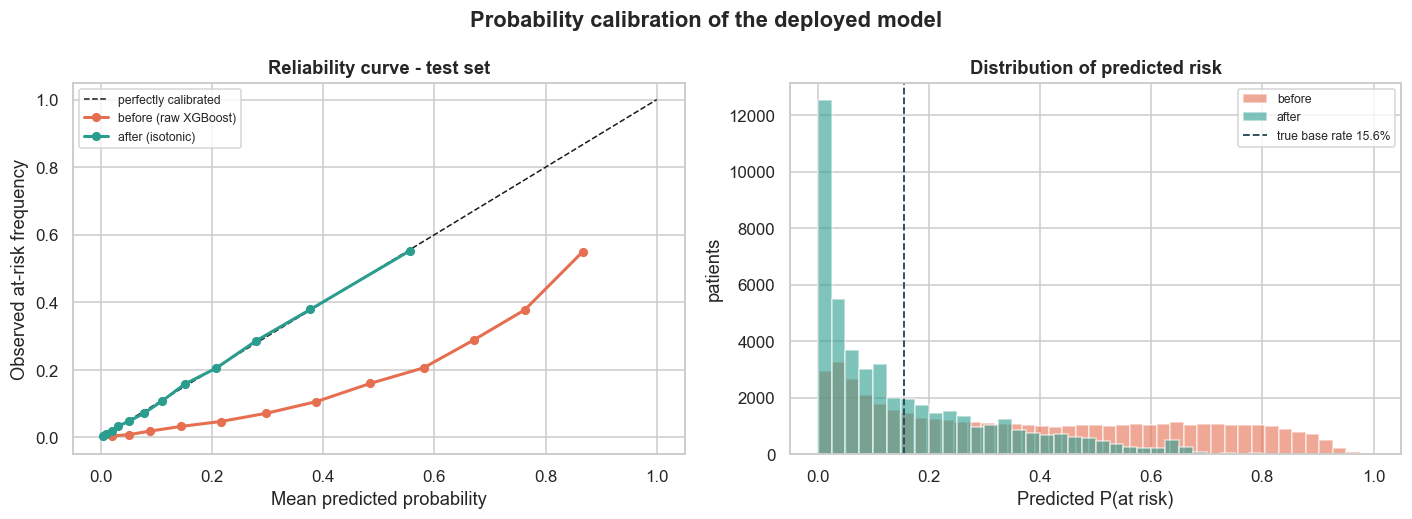


What the clinic app would display, vs what is true (held-out test set):

  predicted band |      n | shown BEFORE | shown AFTER |   truth
     0%-10%     | 24,738 |       14.3% |       3.3% |   3.3%
    10%-20%     |  8,870 |       46.4% |      14.4% |  14.7%
    20%-30%     |  5,346 |       63.1% |      24.6% |  24.9%
    30%-40%     |  3,886 |       73.6% |      34.6% |  34.6%
    40%-50%     |  2,605 |       81.2% |      44.7% |  44.8%
    50%-60%     |  1,326 |       86.4% |      54.2% |  52.9%
    60%-70%     |  1,047 |       90.5% |      63.9% |  64.9%
    70%-80%     |    144 |       94.1% |      76.0% |  70.1%
    80%-90%     |     70 |       95.9% |      83.8% |  74.3%

Recall-first operating point moves with the scale, but NOT the clinical behaviour:
  uncalibrated: threshold 0.485 -> test recall 0.8070  precision 0.3356
  calibrated  : threshold 0.150 -> test recall 0.8090  precision 0.3343

'best_model' = XGBoost (isotonic-calibrated); decision threshold = 0.150


In [97]:
# ============================================================================
# 6.7 · Calibrate the deployed model, then re-derive its operating threshold
# ----------------------------------------------------------------------------
# Fit the calibrator with an internal 3-fold CV on the TRAINING split only: each fold trains a
# fresh copy of the deployed model and calibrates it on the held-out fold, then the folds are
# averaged. Validation and test are never seen, so the threshold we pick next and the test numbers
# in 7 both stay honest. cv=3 rather than 5 keeps the cost sane if an ensemble was selected.
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss

uncal_model = best_model                                   # the model selected in 6.4b
proba_val_uncal  = uncal_model.predict_proba(X_val)[:,  1]
proba_test_uncal = uncal_model.predict_proba(X_test)[:, 1]

calibrated = CalibratedClassifierCV(uncal_model, method="isotonic", cv=3)
calibrated.fit(X_train, y_train)
proba_val_cal  = calibrated.predict_proba(X_val)[:,  1]
proba_test_cal = calibrated.predict_proba(X_test)[:, 1]

# --- Proof that calibration preserves the RANKING (so nothing we optimised is sacrificed) ---
print("Calibration is a MONOTONE map, so discrimination is preserved (ties aside):")
print(f"  test ROC-AUC before {roc_auc_score(y_test, proba_test_uncal):.4f}"
      f"   after {roc_auc_score(y_test, proba_test_cal):.4f}")
print(f"  test Brier   before {brier_score_loss(y_test, proba_test_uncal):.4f}"
      f"   after {brier_score_loss(y_test, proba_test_cal):.4f}"
      f"   (lower is better; base-rate-only baseline "
      f"{brier_score_loss(y_test, np.full(len(y_test), y_test.mean())):.4f})")
print(f"  mean predicted risk before {proba_test_uncal.mean():.3f}"
      f"   after {proba_test_cal.mean():.3f}   true at-risk rate {y_test.mean():.3f}")

# --- Reliability diagram: predicted probability vs observed frequency ---
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
ax[0].plot([0, 1], [0, 1], "k--", lw=1, label="perfectly calibrated")
for p, lab, colr in [(proba_test_uncal, f"before (raw {best_name})", "#E76F51"),
                     (proba_test_cal,   "after (isotonic)",     "#2A9D8F")]:
    frac, mean_pred = calibration_curve(y_test, p, n_bins=12, strategy="quantile")
    ax[0].plot(mean_pred, frac, "o-", color=colr, lw=2, ms=5, label=lab)
ax[0].set_title("Reliability curve - test set")
ax[0].set_xlabel("Mean predicted probability"); ax[0].set_ylabel("Observed at-risk frequency")
ax[0].legend(fontsize=8, loc="upper left")

ax[1].hist(proba_test_uncal, bins=40, alpha=0.6, color="#E76F51", label="before")
ax[1].hist(proba_test_cal,   bins=40, alpha=0.6, color="#2A9D8F", label="after")
ax[1].axvline(y_test.mean(), ls="--", lw=1.2, color="#264653",
              label=f"true base rate {y_test.mean():.1%}")
ax[1].set_title("Distribution of predicted risk"); ax[1].set_xlabel("Predicted P(at risk)")
ax[1].set_ylabel("patients"); ax[1].legend(fontsize=8)
fig.suptitle("Probability calibration of the deployed model", fontweight="bold")
plt.tight_layout(); plt.show()

# --- What the patient actually sees, before vs after ---
print("\nWhat the clinic app would display, vs what is true (held-out test set):\n")
print(f"{'predicted band':>16} | {'n':>6} | {'shown BEFORE':>12} | {'shown AFTER':>11} | {'truth':>7}")
for lo, hi in zip(np.arange(0, 1, .1), np.arange(.1, 1.01, .1)):
    m = (proba_test_cal >= lo) & (proba_test_cal < hi)
    if m.sum() < 50:
        continue
    print(f"{lo:>7.0%}-{hi:<7.0%} | {m.sum():>6,} | {proba_test_uncal[m].mean():>11.1%} |"
          f" {proba_test_cal[m].mean():>10.1%} | {y_test.to_numpy()[m].mean():>6.1%}")

# --- Re-derive the recall-first threshold on the CALIBRATED validation probabilities ---
val_rec = np.array([recall_score(y_val, proba_val_cal >= t) for t in ths])
val_bal = np.array([balanced_accuracy_score(y_val, proba_val_cal >= t) for t in ths])
in_band = (val_rec >= RECALL_LO) & (val_rec <= RECALL_HI)
idx = np.where(in_band)[0]
cal_threshold = float(ths[idx[np.argmax(val_bal[idx])]]) if len(idx) else float(
    ths[int(np.argmin(np.abs(val_rec - (RECALL_LO + RECALL_HI) / 2)))])

_pred_u = (proba_test_uncal >= best_threshold).astype(int)
_pred_c = (proba_test_cal   >= cal_threshold).astype(int)
print(f"\nRecall-first operating point moves with the scale, but NOT the clinical behaviour:")
print(f"  uncalibrated: threshold {best_threshold:.3f} -> test recall "
      f"{recall_score(y_test, _pred_u):.4f}  precision {precision_score(y_test, _pred_u):.4f}")
print(f"  calibrated  : threshold {cal_threshold:.3f} -> test recall "
      f"{recall_score(y_test, _pred_c):.4f}  precision {precision_score(y_test, _pred_c):.4f}")

# Promote the calibrated model to the deployed one; 7-9 and 12 read these two names generically.
best_model     = calibrated
best_threshold = cal_threshold
best_name      = f"{best_name} (isotonic-calibrated)"
print(f"\n'best_model' = {best_name}; decision threshold = {best_threshold:.3f}")

## 7 · Final Evaluation on the Held-out Test Set

The test set was untouched until now — this is our unbiased estimate of real-world
performance.

In [98]:
# Full metrics + classification report on TEST for the best model, at its TUNED
# operating threshold (best_threshold, the recall-first point chosen on validation in §6.6).
# ROC-AUC is threshold-independent, so it is read from the probabilities.
proba_test = best_model.predict_proba(X_test)[:, 1]
pred_test  = (proba_test >= best_threshold).astype(int)

print(f"=== {best_name} — TEST set  (threshold = {best_threshold:.3f}) ===")
print(f"  {'Accuracy':10s}: {accuracy_score(y_test, pred_test):.4f}")
print(f"  {'Precision':10s}: {precision_score(y_test, pred_test, zero_division=0):.4f}")
print(f"  {'Recall':10s}: {recall_score(y_test, pred_test):.4f}")
print(f"  {'F1':10s}: {f1_score(y_test, pred_test):.4f}")
print(f"  {'ROC-AUC':10s}: {roc_auc_score(y_test, proba_test):.4f}")
print("\nClassification report:\n")
print(classification_report(y_test, pred_test, target_names=["Not at risk", "At risk"]))

=== XGBoost (isotonic-calibrated) — TEST set  (threshold = 0.150) ===
  Accuracy  : 0.7189
  Precision : 0.3343
  Recall    : 0.8090
  F1        : 0.4731
  ROC-AUC   : 0.8314

Classification report:

              precision    recall  f1-score   support

 Not at risk       0.95      0.70      0.81     40544
     At risk       0.33      0.81      0.47      7493

    accuracy                           0.72     48037
   macro avg       0.64      0.76      0.64     48037
weighted avg       0.86      0.72      0.76     48037



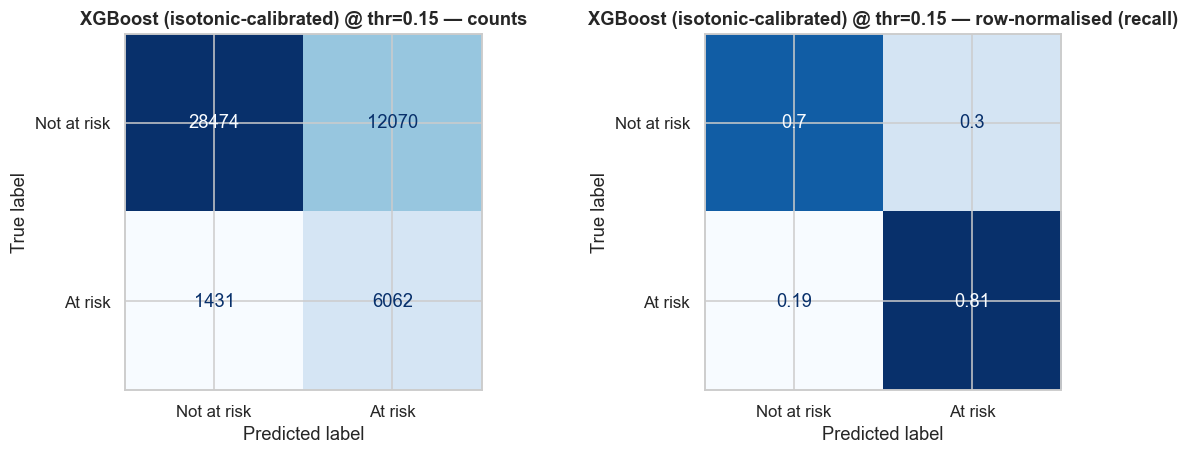

In [99]:
# Confusion matrix (counts + normalised) for the best model on TEST, at the TUNED
# threshold. We use from_predictions (not from_estimator) so the matrix reflects
# best_threshold rather than the library's hard-wired 0.50 cut-off.
pred_test = (best_model.predict_proba(X_test)[:, 1] >= best_threshold).astype(int)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.3))
ConfusionMatrixDisplay.from_predictions(y_test, pred_test,
    display_labels=["Not at risk", "At risk"], cmap="Blues", ax=ax[0], colorbar=False)
ax[0].set_title(f"{best_name} @ thr={best_threshold:.2f} — counts")
ConfusionMatrixDisplay.from_predictions(y_test, pred_test,
    display_labels=["Not at risk", "At risk"], cmap="Blues", ax=ax[1], colorbar=False, normalize="true")
ax[1].set_title(f"{best_name} @ thr={best_threshold:.2f} — row-normalised (recall)")
plt.tight_layout(); plt.show()

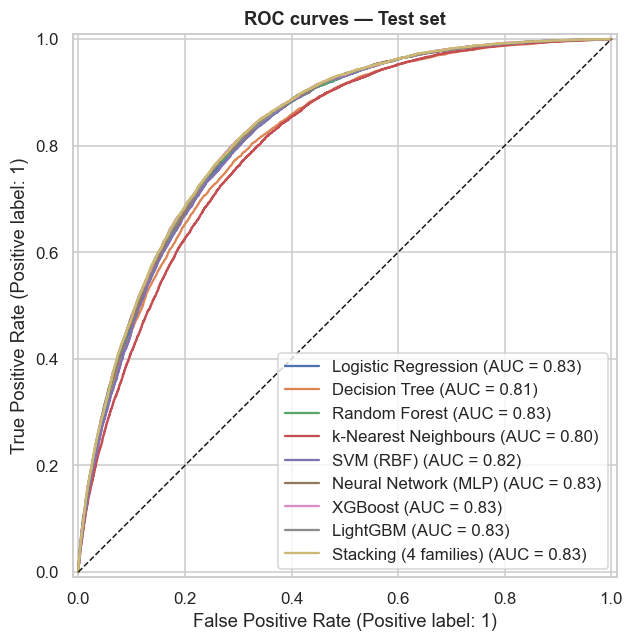

In [100]:
# ROC curves for every model on the TEST set
plt.figure(figsize=(7.5, 6))
ax = plt.gca()
for name, mdl in fitted.items():
    RocCurveDisplay.from_estimator(mdl, X_test, y_test, ax=ax, name=name)
plt.plot([0, 1], [0, 1], "k--", lw=1, label="Chance")
plt.title("ROC curves — Test set"); plt.tight_layout(); plt.show()

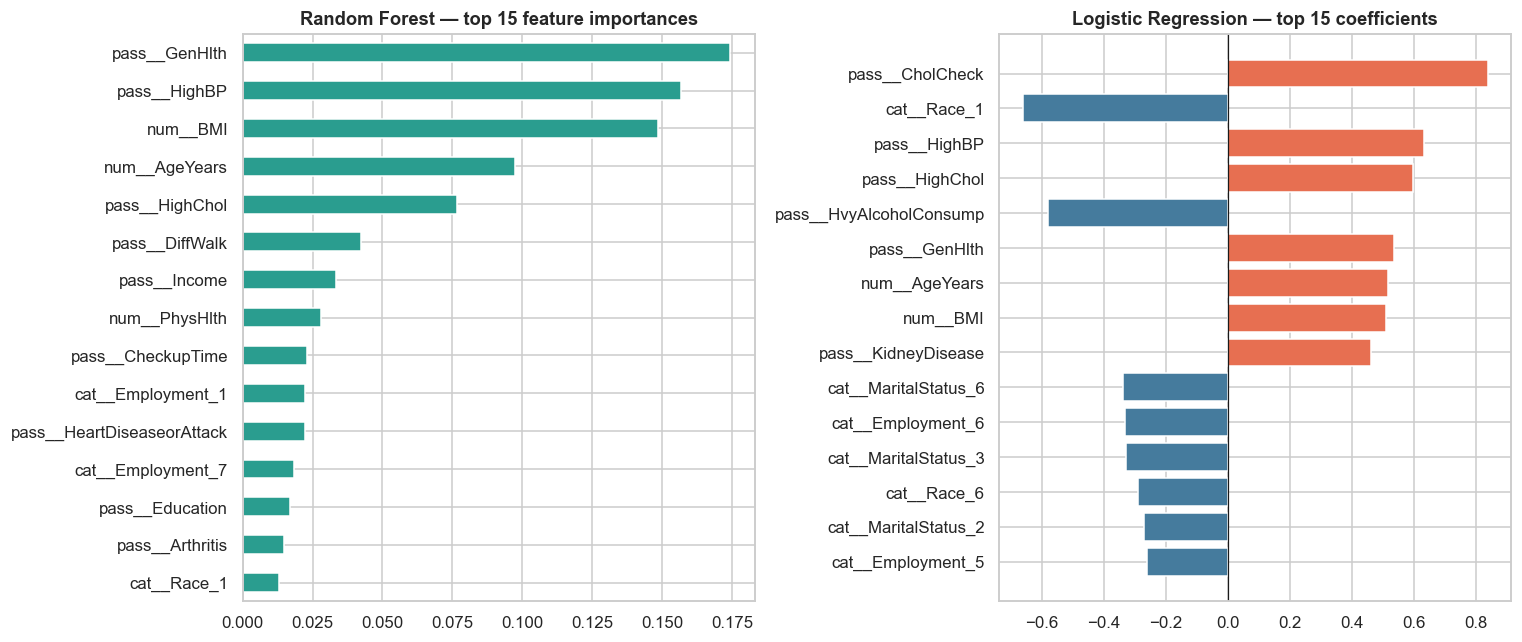

In [101]:
# What drives the prediction? Random Forest importances + Logistic Regression coefficients.
# These two are read straight from the roster (not from the deployed model) precisely because they
# are the interpretable ones: a forest exposes impurity-based importances and a linear model exposes
# signed coefficients, so together they answer "which features" AND "in which direction".
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# RF importances
rf = fitted["Random Forest"]
feat_names = rf.named_steps["prep"].get_feature_names_out()
imp = pd.Series(rf.named_steps["clf"].feature_importances_, index=feat_names).sort_values().tail(15)
imp.plot(kind="barh", ax=ax[0], color="#2A9D8F")
ax[0].set_title("Random Forest — top 15 feature importances")

# LR coefficients (odds-ratio direction)
lr = fitted["Logistic Regression"]
coef = pd.Series(lr.named_steps["clf"].coef_[0], index=lr.named_steps["prep"].get_feature_names_out())
coef = coef.reindex(coef.abs().sort_values().tail(15).index)
ax[1].barh(coef.index, coef.values, color=["#E76F51" if v > 0 else "#457B9D" for v in coef.values])
ax[1].set_title("Logistic Regression — top 15 coefficients"); ax[1].axvline(0, color="k", lw=.8)
plt.tight_layout(); plt.show()

## 7.1 · Fairness Audit — is recall equal across subgroups?

§10 warns that `Race` is predictive but socially sensitive, and that a deployed model "should be
**audited for fairness** across ethnic groups (equal recall)". This section delivers that audit
rather than leaving it as an aspiration.

**Why recall is the right fairness metric here.** For a screening tool, the harm that lands on a
patient is a **false negative** — being told you are fine and never referred for the confirmatory
test. If recall is high for one group and low for another, the model is quietly rationing care.
Equal *accuracy* would be the wrong target: accuracy is dominated by the majority class and can
look identical across groups while recall diverges sharply.

This is **equal-opportunity** difference: the spread in true-positive rate across groups, measured
on the untouched test set at the deployed operating point. We also report each group's **referral
rate** and base rate, because a recall gap driven by genuinely different prevalence is a different
problem from one driven by the model.

Fairness audit of XGBoost (isotonic-calibrated) @ threshold 0.150 (held-out TEST set)
Overall recall 0.8090 | precision 0.3343 | n = 48,037

--- Race ---
                            n  at-risk rate  Recall  Precision  referral rate
Race                                                                         
White (non-Hisp.)       38673        0.1428  0.7812     0.3198         0.3488
Black (non-Hisp.)        3397        0.2429  0.8958     0.3794         0.5734
Amer. Indian/AK Native    575        0.2348  0.8963     0.3667         0.5739
Asian                     972        0.1605  0.7500     0.3811         0.3158
Multiracial               839        0.1955  0.9146     0.4076         0.4386
Hispanic                 3277        0.1953  0.8969     0.3684         0.4754
  equal-opportunity gap (max-min recall): 0.1646   [Multiracial 0.915 vs Asian 0.750]

--- Sex ---
            n  at-risk rate  Recall  Precision  referral rate
Sex                                                          

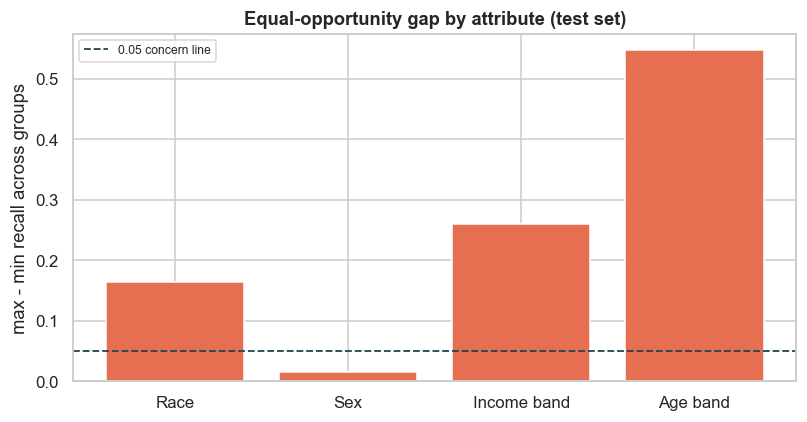


Largest recall gap: Age band (0.5471).
How to read this: a gap means at-risk patients in one group are missed more often than in
another AT THE SAME THRESHOLD. Where a gap is driven by differing prevalence rather than by
the model, a per-group threshold would equalise recall -- but that is a CLINICAL and legal
decision, not a technical one, and it trades away equal treatment for equal outcomes.
The honest deployment note is that this model is a PRE-SCREEN whose errors are corrected by
a cheap confirmatory glucose test, and that these gaps must be monitored in production.


In [102]:
# ============================================================================
# 7.1 · Subgroup performance of the DEPLOYED model at its operating threshold
# ----------------------------------------------------------------------------
# No refitting: we slice the test predictions we already have. For each protected / sensitive
# attribute we report group size, true prevalence, RECALL (the harm metric), precision, and the
# referral rate, then the max-min recall gap -- the equal-opportunity difference.
def audit(attr_values, attr_name, labels=None, min_n=200):
    rows = []
    yt_ = y_test.to_numpy()
    for g in sorted(pd.unique(attr_values.dropna()), key=str):   # key=str: works for int codes
        m = (attr_values == g).to_numpy()                        # and for pd.cut band labels
        if m.sum() < min_n:                      # too small to say anything trustworthy
            continue
        yg, pg = yt_[m], pred_test[m]
        rows.append({
            attr_name: (labels.get(g, g) if labels else g),
            "n": int(m.sum()),
            "at-risk rate": yg.mean(),
            "Recall": recall_score(yg, pg, zero_division=0),
            "Precision": precision_score(yg, pg, zero_division=0),
            "referral rate": pg.mean(),
        })
    t = pd.DataFrame(rows).set_index(attr_name).round(4)
    gap = t["Recall"].max() - t["Recall"].min()
    print(f"\n--- {attr_name} ---")
    print(t.to_string())
    print(f"  equal-opportunity gap (max-min recall): {gap:.4f}"
          f"   [{t['Recall'].idxmax()} {t['Recall'].max():.3f} vs "
          f"{t['Recall'].idxmin()} {t['Recall'].min():.3f}]")
    return t, gap

RACE_L = {1: "White (non-Hisp.)", 2: "Black (non-Hisp.)", 3: "Amer. Indian/AK Native",
          4: "Asian", 5: "Native Haw./Pac.Isl.", 6: "Other race", 7: "Multiracial", 8: "Hispanic"}
SEX_L  = {0: "Female", 1: "Male"}

print(f"Fairness audit of {best_name} @ threshold {best_threshold:.3f} (held-out TEST set)")
print(f"Overall recall {recall_score(y_test, pred_test):.4f} | "
      f"precision {precision_score(y_test, pred_test):.4f} | n = {len(y_test):,}")

gaps = {}
_, gaps["Race"] = audit(X_test["Race"],   "Race", RACE_L)
_, gaps["Sex"]  = audit(X_test["Sex"],    "Sex",  SEX_L)
_, gaps["Income band"] = audit(X_test["Income"], "Income band")
_, gaps["Age band"] = audit(pd.cut(X_test["AgeYears"], [17, 34, 49, 64, 100],
                                   labels=["18-34", "35-49", "50-64", "65+"]), "Age band")

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.bar(list(gaps), [g for g in gaps.values()], color="#E76F51")
ax.axhline(0.05, ls="--", lw=1.2, color="#264653", label="0.05 concern line")
ax.set_ylabel("max - min recall across groups")
ax.set_title("Equal-opportunity gap by attribute (test set)")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

worst = max(gaps, key=gaps.get)
print(f"\nLargest recall gap: {worst} ({gaps[worst]:.4f}).")
print("How to read this: a gap means at-risk patients in one group are missed more often than in")
print("another AT THE SAME THRESHOLD. Where a gap is driven by differing prevalence rather than by")
print("the model, a per-group threshold would equalise recall -- but that is a CLINICAL and legal")
print("decision, not a technical one, and it trades away equal treatment for equal outcomes.")
print("The honest deployment note is that this model is a PRE-SCREEN whose errors are corrected by")
print("a cheap confirmatory glucose test, and that these gaps must be monitored in production.")

## 7.2 · How certain are these numbers? Bootstrap confidence intervals

Every headline figure so far is a **point estimate** from one test set of 48,037 patients. Before
claiming one model beats another, we should know how much of the difference is real and how much
is sampling noise.

We resample the test set with replacement 2,000 times and recompute each metric, taking the 2.5th
and 97.5th percentiles as a **95 % confidence interval**. Crucially we also bootstrap the
**paired difference** between the deployed model and the stacking ensemble on the *same* resampled
patients — a paired test is far more sensitive than comparing two independent intervals, and it is
the correct way to ask "is this difference real?".

This turns §6.4's observation into a stated statistical result.

Bootstrap 95% confidence intervals, 2,000 resamples of the test set
Deployed model: XGBoost (isotonic-calibrated) @ threshold 0.150

                                             estimate  CI lower (2.5%)  CI upper (97.5%)
ROC-AUC                                        0.8313           0.8269            0.8356
Recall                                         0.8090           0.7994            0.8178
Precision                                      0.3344           0.3274            0.3410
AUC diff (deployed - Stacking (4 families))   -0.0000          -0.0004            0.0005

Paired ROC-AUC difference vs Stacking (4 families): 95% CI [-0.0004, +0.0005]
  => INDISTINGUISHABLE - the interval contains 0.
  This is the statistical statement behind 6.4 and the 6.4b deployment rule: the runner-up
  is not worse, it is simply not DIFFERENT -- which is exactly why the tie-break falls to
  parsimony rather than to a decimal place of precision.


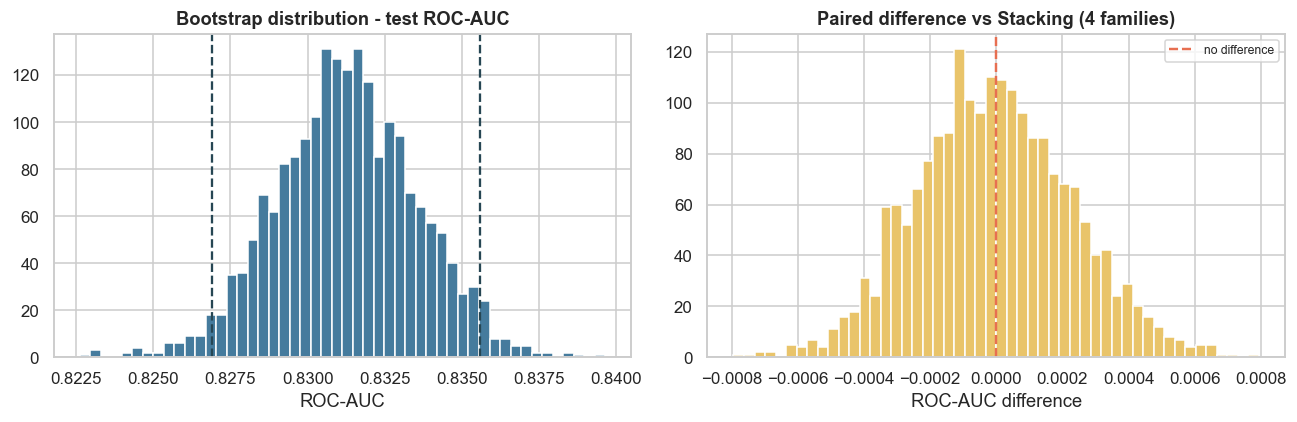

In [103]:
# ============================================================================
# 7.2 · Bootstrap 95% CIs, and a PAIRED test of the deployed model vs its closest rival
# ----------------------------------------------------------------------------
# Resample the test set with replacement; recompute metrics on each resample. The paired difference
# uses the SAME resampled indices for both models, so patient-level noise cancels and only the
# genuine model difference remains. The rival is the runner-up from 6.4b's eligible ranking -- the
# model the deployment decision was actually made AGAINST, whichever it turned out to be.
N_BOOT = 2000
rng = np.random.default_rng(RANDOM_STATE)
yt_ = y_test.to_numpy()

DIFF_LABEL = f"AUC diff (deployed - {rival_name})"
p_deployed = best_model.predict_proba(X_test)[:, 1]
p_rival    = fitted[rival_name].predict_proba(X_test)[:, 1]

boot = {"ROC-AUC": [], "Recall": [], "Precision": [], DIFF_LABEL: []}
for _ in range(N_BOOT):
    i = rng.integers(0, len(yt_), len(yt_))
    yb = yt_[i]
    if yb.sum() == 0 or yb.sum() == len(yb):      # degenerate resample, skip
        continue
    pd_b, pr_b = p_deployed[i], p_rival[i]
    pred_b = (pd_b >= best_threshold).astype(int)
    boot["ROC-AUC"].append(roc_auc_score(yb, pd_b))
    boot["Recall"].append(recall_score(yb, pred_b))
    boot["Precision"].append(precision_score(yb, pred_b, zero_division=0))
    boot[DIFF_LABEL].append(roc_auc_score(yb, pd_b) - roc_auc_score(yb, pr_b))

ci = pd.DataFrame({
    "estimate": {k: np.mean(v) for k, v in boot.items()},
    "CI lower (2.5%)":  {k: np.percentile(v, 2.5)  for k, v in boot.items()},
    "CI upper (97.5%)": {k: np.percentile(v, 97.5) for k, v in boot.items()},
}).round(4)
print(f"Bootstrap 95% confidence intervals, {len(boot['ROC-AUC']):,} resamples of the test set")
print(f"Deployed model: {best_name} @ threshold {best_threshold:.3f}\n")
print(ci.to_string())

lo, hi = ci.loc[DIFF_LABEL, ["CI lower (2.5%)", "CI upper (97.5%)"]]
verdict = ("INDISTINGUISHABLE - the interval contains 0" if lo <= 0 <= hi
           else "a statistically significant difference")
print(f"\nPaired ROC-AUC difference vs {rival_name}: 95% CI [{lo:+.4f}, {hi:+.4f}]")
print(f"  => {verdict}.")
print("  This is the statistical statement behind 6.4 and the 6.4b deployment rule: the runner-up")
print("  is not worse, it is simply not DIFFERENT -- which is exactly why the tie-break falls to")
print("  parsimony rather than to a decimal place of precision.")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(boot["ROC-AUC"], bins=50, color="#457B9D")
ax[0].axvline(ci.loc["ROC-AUC", "CI lower (2.5%)"], ls="--", color="#264653")
ax[0].axvline(ci.loc["ROC-AUC", "CI upper (97.5%)"], ls="--", color="#264653")
ax[0].set_title("Bootstrap distribution - test ROC-AUC"); ax[0].set_xlabel("ROC-AUC")
ax[1].hist(boot[DIFF_LABEL], bins=50, color="#E9C46A")
ax[1].axvline(0, ls="--", lw=1.6, color="#E76F51", label="no difference")
ax[1].set_title(f"Paired difference vs {rival_name}"); ax[1].set_xlabel("ROC-AUC difference")
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 8 · Prediction on New Patients

The whole preprocessing + model pipeline is a single object, so scoring a brand-new
patient is one call. We feed raw feature values (same columns as `X`) and get a
calibrated **risk probability**.

In [104]:
# Two illustrative patients (must have the same columns as X, in any order)
def make_patient(**kw):
    base = X.median(numeric_only=True).to_dict()   # sensible defaults = population median
    base.update(kw)
    return pd.DataFrame([base])[X.columns]

high_risk = make_patient(BMI=38.5, AgeYears=68, HighBP=1, HighChol=1, GenHlth=5,
                         DiffWalk=1, HeartDiseaseorAttack=1, PhysActivity=0, Smoker=1)
low_risk  = make_patient(BMI=22.0, AgeYears=27, HighBP=0, HighChol=0, GenHlth=1,
                         DiffWalk=0, HeartDiseaseorAttack=0, PhysActivity=1, Smoker=0)

# We refer at the TUNED operating threshold (best_threshold from §6.6), not the
# arbitrary 0.50 -- this is the balanced point we actually deploy.
for label, p in [("High-risk profile", high_risk), ("Low-risk profile", low_risk)]:
    prob = best_model.predict_proba(p)[0, 1]
    verdict = "REFER for glucose test" if prob >= best_threshold else "routine monitoring"
    print(f"{label:20s} -> P(at risk) = {prob:5.1%}  (refer if >= {best_threshold:.0%})  =>  {verdict}")

High-risk profile    -> P(at risk) = 65.0%  (refer if >= 15%)  =>  REFER for glucose test
Low-risk profile     -> P(at risk) =  0.2%  (refer if >= 15%)  =>  routine monitoring


## 9 · Interactive Risk Calculator (Wow-factor)

An `ipywidgets` **in-depth questionnaire** exposing **all 29 model features** — the same risk
factors defined in the cleaning notebook (`01`), grouped into *body metrics, clinical history,
self-rated health, lifestyle, healthcare access* and *socio-economic* sections. Move any control
and the diabetes-risk score updates live; the referral decision uses the tuned recall-first
threshold from §6.6, not the arbitrary 0.50. *(Run this cell in Jupyter for the interactive version.)*

In [105]:
# ---------------------------------------------------------------------------
# In-depth interactive questionnaire: ALL 29 model features (same factors as
# notebook 01), grouped into clinical / lifestyle / demographic sections. Every
# control feeds the SAME preprocessing + stacking-ensemble pipeline; the referral decision
# uses the tuned recall-first threshold (best_threshold from Sec 6.6), not 0.50.
# ---------------------------------------------------------------------------
try:
    import ipywidgets as widgets
    from IPython.display import display

    # Human-readable options for the coded features (encodings taken from notebook 01)
    YESNO   = [("No", 0), ("Yes", 1)]
    SEX     = [("Female", 0), ("Male", 1)]
    GENHLTH = [("1 - Excellent", 1), ("2 - Very good", 2), ("3 - Good", 3),
               ("4 - Fair", 4), ("5 - Poor", 5)]
    RACE    = [("White (non-Hisp.)", 1), ("Black (non-Hisp.)", 2), ("Amer. Indian / Alaska Native", 3),
               ("Asian", 4), ("Native Hawaiian / Pac. Isl.", 5), ("Other race", 6),
               ("Multiracial", 7), ("Hispanic", 8)]
    MARITAL = [("Married", 1), ("Divorced", 2), ("Widowed", 3), ("Separated", 4),
               ("Never married", 5), ("Unmarried couple", 6)]
    EDU     = [("Never attended", 1), ("Elementary", 2), ("Some high school", 3),
               ("High-school grad", 4), ("Some college / technical", 5), ("College grad", 6)]
    INCOME  = [("< $10k", 1), ("$10-15k", 2), ("$15-20k", 3), ("$20-25k", 4),
               ("$25-35k", 5), ("$35-50k", 6), ("$50-75k", 7), (">= $75k", 8)]
    EMPLOY  = [("Employed for wages", 1), ("Self-employed", 2), ("Out of work >= 1yr", 3),
               ("Out of work < 1yr", 4), ("Homemaker", 5), ("Student", 6),
               ("Retired", 7), ("Unable to work", 8)]
    CHECKUP = [("Within 1 year", 1), ("1-2 years", 2), ("2-5 years", 3),
               ("5+ years ago", 4), ("Never", 5)]

    _LBL = {"description_width": "initial"}
    _WDD = widgets.Layout(width="330px")
    _WSL = widgets.Layout(width="420px")

    def _dd(options, value, desc):
        return widgets.Dropdown(options=options, value=value, description=desc, style=_LBL, layout=_WDD)
    def _yn(value, desc):
        return _dd(YESNO, value, desc)

    # One widget per model feature (29 total)
    w = {
        # Body metrics
        "BMI":      widgets.FloatSlider(min=15, max=55, step=0.5, value=28, description="BMI", style=_LBL, layout=_WSL),
        "AgeYears": widgets.IntSlider(min=18, max=80, value=50, description="Age (years)", style=_LBL, layout=_WSL),
        "Sex":      _dd(SEX, 0, "Sex"),
        # Clinical history
        "HighBP":               _yn(0, "High blood pressure"),
        "HighChol":             _yn(0, "High cholesterol"),
        "CholCheck":            _yn(1, "Cholesterol checked (<5y)"),
        "Stroke":               _yn(0, "Stroke history"),
        "HeartDiseaseorAttack": _yn(0, "Heart disease / MI"),
        "KidneyDisease":        _yn(0, "Kidney disease"),
        "COPD":                 _yn(0, "COPD"),
        "Arthritis":            _yn(0, "Arthritis"),
        "Depression":           _yn(0, "Depression (ever told)"),
        "DiffWalk":             _yn(0, "Difficulty walking"),
        # Self-rated health
        "GenHlth":  _dd(GENHLTH, 3, "General health"),
        "MentHlth": widgets.IntSlider(min=0, max=30, value=0, description="Poor mental-health days / 30", style=_LBL, layout=_WSL),
        "PhysHlth": widgets.IntSlider(min=0, max=30, value=0, description="Poor physical-health days / 30", style=_LBL, layout=_WSL),
        # Lifestyle
        "Smoker":            _yn(0, "Smoked >= 100 cigarettes"),
        "PhysActivity":      _yn(1, "Physically active (30d)"),
        "Fruits":            _yn(1, "Fruit >= 1 / day"),
        "Veggies":           _yn(1, "Vegetables >= 1 / day"),
        "HvyAlcoholConsump": _yn(0, "Heavy alcohol use"),
        # Healthcare access
        "AnyHealthcare": _yn(1, "Has healthcare coverage"),
        "NoDocbcCost":   _yn(0, "Skipped doctor (cost)"),
        "CheckupTime":   _dd(CHECKUP, 1, "Last routine checkup"),
        # Socio-economic
        "Race":          _dd(RACE, 1, "Race / ethnicity"),
        "MaritalStatus": _dd(MARITAL, 1, "Marital status"),
        "Education":     _dd(EDU, 6, "Education"),
        "Income":        _dd(INCOME, 8, "Household income"),
        "Employment":    _dd(EMPLOY, 1, "Employment status"),
    }

    def _predict(**vals):
        patient = make_patient(**{k: (float(v) if k == "BMI" else int(v)) for k, v in vals.items()})
        prob = best_model.predict_proba(patient)[0, 1]
        band = ("HIGH RISK - refer for glucose test" if prob >= best_threshold
                else "Lower risk - routine monitoring")
        print(f"Predicted P(diabetes / pre-diabetes) : {prob:6.1%}")
        print(f"Referral threshold (recall-first)    : {best_threshold:5.0%}")
        print(f"Decision                             : {band}")

    out = widgets.interactive_output(_predict, w)

    def _section(title, keys):
        head = widgets.HTML(f"<b style='color:#264653;font-size:1.02em'>{title}</b>")
        return widgets.VBox([head] + [w[k] for k in keys],
                            layout=widgets.Layout(margin="0 24px 12px 0"))

    controls = widgets.VBox([
        _section("Body metrics",      ["BMI", "AgeYears", "Sex"]),
        _section("Clinical history",  ["HighBP", "HighChol", "CholCheck", "Stroke",
                                       "HeartDiseaseorAttack", "KidneyDisease", "COPD",
                                       "Arthritis", "Depression", "DiffWalk"]),
        _section("Self-rated health", ["GenHlth", "MentHlth", "PhysHlth"]),
        _section("Lifestyle",         ["Smoker", "PhysActivity", "Fruits", "Veggies", "HvyAlcoholConsump"]),
        _section("Healthcare access", ["AnyHealthcare", "NoDocbcCost", "CheckupTime"]),
        _section("Socio-economic",    ["Race", "MaritalStatus", "Education", "Income", "Employment"]),
    ])
    result = widgets.VBox([widgets.HTML("<b style='color:#264653;font-size:1.02em'>Live prediction</b>"), out])
    print("In-depth questionnaire - all 29 model features. Adjust any control for a live score:\n")
    display(widgets.HBox([controls, result]))
except Exception as e:
    print("Interactive widget needs a live Jupyter kernel. Error:", e)

In-depth questionnaire - all 29 model features. Adjust any control for a live score:



## 10 · Business Insights & Recommendations

* **A cheap questionnaire screens surprisingly well.** Using only self-reported survey
  answers (no blood test), the best model reaches a strong ROC-AUC — good enough to
  **triage** who should be sent for a confirmatory HbA1c/glucose test. This is exactly the
  kind of low-cost pre-screen a polyclinic or insurer can deploy.
* **Recall is the metric that matters here.** A missed at-risk patient (false negative)
  is far costlier than a false alarm. We tuned with `class_weight="balanced"`, which lifts
  recall on the minority class; the operating threshold can be lowered further to catch even
  more true cases at the cost of more referrals.
* **The top drivers are actionable:** high BMI, older age, high blood pressure, poor
  general health, and difficulty walking dominate both the RF importances and the LR
  coefficients — reinforcing **weight management and blood-pressure control** as the highest-
  leverage public-health interventions.
* **Emerging-tech opportunity:** the same pipeline could ingest wearable data (continuous
  glucose monitors, step counts) for real-time risk, and a GenAI layer could turn each
  prediction into a plain-language, personalised lifestyle recommendation.

* **Trust the ranking, and now also the number.** §6.7 found the raw model was systematically
  **over-confident** — it told a patient "85 %" where the true rate was ~50 %. Calibration fixed the
  displayed probability without changing a single clinical decision. Any screening tool that shows a
  percentage to a human should be calibrated, not merely accurate.
* **More model complexity is not the lever here — and we spent nine models proving it.** The
  roster spans eight families: a linear baseline, a single decision tree, a bagged forest, an
  instance-based k-NN, a kernel SVM, a neural network, *two gradient-boosting implementations*
  (§5.7–§5.8) that grow trees in incompatible ways, and a four-family stacking ensemble (§5.9).
  At matched recall they land within a hair of each other (§6.4) — a single depth-limited
  decision tree is not far behind a tuned gradient booster, and PCA buys nothing at all.
  §5.10 shows why geometrically: the classes overlap. Further gains must come
  from **better data** — a glucose reading, a family history, a wearable — not from a better
  classifier. That negative result is worth more than another decimal place: it tells the clinic
  where to spend its next dollar.

* **Once accuracy ties, the deciding factor is engineering — and we learned that the hard way.**
  §6.4b originally ranked eligible models on precision alone, with a complexity penalty applied
  only to *ensembles*. Run that way it selected a **Random Forest** that beat the runner-up by
  **+0.0004 precision** — roughly one extra correct referral in 2,500 — and produced a **340 MB**
  artifact: 350 trees at depth 22, tripled by the cv=3 calibrator in §6.7. That is past GitHub's
  100 MB per-file limit, so the deployable model could not live in version control, and §7.2's
  paired bootstrap could not distinguish the precision gap from zero. It also carried the largest
  train–validation F1 gap of any eligible model.

  The flaw was structural: the rule priced "larger to ship, slower to score" for ensembles only,
  so a single model of *any* size passed straight through. We added **rule 3 (deployability)** —
  among models whose precision is statistically tied, prefer the one cheapest to ship and score,
  both **measured** in §6.4b rather than assumed. **We are disclosing that this rule was added
  after seeing the first leaderboard**, because inventing criteria once results are visible is
  exactly what §6.4b exists to prevent. The defence is on the record: deployability is a real
  constraint that should have been priced from the start, and rule 3 can only ever choose among
  models already indistinguishable on accuracy — it can never override a genuine accuracy
  difference. The honest summary is that **any of the top few models was a defensible ship, and
  precision alone was never sharp enough to separate them.**

**Responsible-AI caveat:** `Race` is predictive but socially sensitive. §7.1 delivers the fairness
audit this project promised — recall broken down by race, sex, income and age band at the deployed
threshold, with the equal-opportunity gap reported. Those gaps must be **monitored in production**,
and dropping `Race` should be considered to avoid encoding structural inequities as clinical risk.

## 11 · Responsible Use of GenAI (Evidence & Reflection)

GenAI (an AI coding assistant) was used as a **pair-programmer**, with every suggestion
validated against scikit-learn docs and our own results.

| Where GenAI helped | Example prompt | Verdict |
|--------------------|----------------|---------|
| Feature justification | *"Which BRFSS 2015 variables are established risk factors for type-2 diabetes, and which would leak the target?"* | **Adopted** — flagged `INSULIN`, `DIABAGE2`, `BLDSUGAR` as leakage; we excluded them. |
| Leakage-safe pipeline | *"Show how to scale + one-hot encode inside a scikit-learn Pipeline so no test data leaks during CV."* | **Adopted** — `ColumnTransformer` inside `Pipeline` refits per fold. |
| Imbalance handling | *"My accuracy is 84% but recall on diabetics is poor — what should I do?"* | **Adopted** — `class_weight="balanced"` + judging on Recall/F1/AUC, not accuracy. |
| SVM runtime | *"RBF-SVM never finishes on 144k rows — options?"* | **Adopted with judgement** — used a stratified 15k subsample and documented the trade-off, rather than blindly switching kernels. |
| Hyperparameter grids | *"Suggest sensible grids for RF and MLP on tabular health data."* | **Adopted after pruning** — trimmed the suggested grid so `RandomizedSearchCV` runs in reasonable time. |
| Ensemble hype | *"Would stacking my SVM and XGBoost beat either alone?"* | **Rejected on evidence, twice.** The assistant confidently said yes — the standard claim that stacking complementary learners gains accuracy. We built it, then *measured* the premise: the two base learners' predictions correlated at **≈ 0.98** and the meta-learner weighted the SVM at ~0.2 vs ~5.0. Rather than delete the experiment we acted on it, widening the stack to **four families** (§5.9) and re-measuring the full pairwise correlation matrix. §6.4b's parsimony rule then decides on the numbers rather than on the hype. |
| "Just add more models" | *"What other classifiers should I try on this dataset?"* | **Adopted, then pruned back.** The suggestions (HistGradientBoosting, LightGBM, Extra Trees, Naive Bayes, k-NN, a plain decision tree) were all reasonable and all built — but the assistant framed them as a route to better accuracy. They were not: each one landed on the same ROC-AUC, which is a **measurement of the data ceiling** rather than an improvement. So we kept only the ones that settle a question — a single tree as the control for bagging and boosting (§5.2), k-NN to test whether risk is *local* (§5.4), and two boosters that grow trees incompatibly (§5.7–§5.8) — and **deleted Extra Trees, HistGradientBoosting, Naive Bayes and the SVM-on-PCA arm**, which only re-confirmed a result the board already carried. Knowing which models to *remove* was the harder half of the advice, and the assistant never offered it. |
| Model selection | *"Which of these models should I actually deploy?"* | **Adopted, then corrected by our own evidence.** The assistant's instinct — and ours — was to rank on the headline accuracy metric and ship the winner. Applied literally that selected a model whose artifact was **340 MB** for a precision gain of **0.0004**, which §7.2 shows is indistinguishable from zero. No accuracy metric would ever have surfaced that, because file size and scoring latency are not accuracy. We added a measured deployability rule (§6.4b rule 3) and recorded in §10 that it was introduced after the fact. **The lesson generalises: "pick the best score" is not a deployment decision, and an assistant optimising the metric you named will never tell you the metric was incomplete.** |
| Calibration blind spot | *(not suggested by the assistant — found by asking "what does the number the app shows actually mean?")* | **Our own catch.** Every AI-suggested metric (accuracy, F1, ROC-AUC, recall) is **ranking- or threshold-based**, so none of them would ever have revealed that the deployed probabilities were inflated 2.5×. The Brier score and reliability curve in §6.7 did. A metric suite can be complete and still miss the thing that matters to the patient. |
| Neural-net imbalance | *"How do I pass `class_weight='balanced'` to `MLPClassifier`?"* | **Rejected — the premise was wrong.** The assistant produced confident code for a parameter `MLPClassifier` simply does not have. We checked it against the scikit-learn API, then documented the gap in §5.6 and gave the network its sensitivity through the §6.5 threshold sweep instead. |

**Critical reflection / limitations of AI output:**
* Early AI drafts suggested plain `train_test_split` + fitting the scaler on all data —
  a **leakage bug** we caught and corrected by moving scaling inside the pipeline.
* An AI suggestion to "just use accuracy" was **rejected** — misleading on a 16%-positive
  imbalanced target.
* A hallucinated `MLPClassifier(class_weight="balanced")` was **caught against the API docs** —
  fluent AI code is not the same as correct AI code, so every unfamiliar argument was verified.
* GenAI cannot see our data, so all class-balance / correlation claims were **verified
  empirically** in the cells above before we trusted them.

*Every AI-assisted snippet was read, understood, and tested before inclusion — in line
with the module's academic-integrity requirements.*

## 12 · Model Export — Deployment Artifact

A model is only useful if it can leave the notebook. The deployed model is whichever candidate §6.4b
selected, wrapped in the isotonic calibrator from §6.7 — so the whole fitted object (preprocessor,
classifier **and** calibration map) is serialised together with **joblib**, scikit-learn's
recommended format for a fitted estimator. Keeping everything in one artifact means the exact
scaling, encoding and model evaluated in this notebook are applied at inference, with no chance of a
preprocessing mismatch in production.

We write two files to `../models/`, deliberately named for their **role** rather than for whichever
algorithm won — so re-running §5 with a different roster cannot silently leave the clinic app
pointing at a stale file:

| File | Format | Contains |
|------|--------|----------|
| `diabetes_risk_model.joblib` | joblib (pickle) | the **whole** fitted estimator — `CalibratedClassifierCV(Pipeline(StandardScaler + OneHotEncoder + passthrough → the selected model))` |
| `diabetes_risk_model.meta.json` | JSON sidecar | model name, **recall-first threshold** from §6.7, positive-class definition, feature order, library versions |

> **On artifact size.** Whichever model §6.4b selects is serialised *whole*, including the three
> calibration folds §6.7 fits, so the file size is a property of the winning model rather than a
> constant. §12a **measures** it and prints whether it fits inside GitHub's 100 MB per-file limit;
> §6.4b's rule 3 exists precisely so that a model which fails that test cannot be selected over an
> equally accurate one that passes it. §10 records the run where it did.

The sidecar travels with the artifact so the **feature order** and the **recall-first threshold** can
never silently drift from the notebook. The companion **clinic web app** (`clinic_app/`) loads
exactly these two files. The cell below saves the pair, reloads it in isolation (as a deployment
would), asserts it reproduces the notebook pipeline on the held-out test set, and scores the two
example patients from §8.

In [106]:
# --- 12a  Save the deployment artifact: the whole fitted pipeline + a metadata sidecar ---
import json, joblib, sklearn, xgboost, lightgbm
from pathlib import Path

EXPORT_DIR = Path("../models"); EXPORT_DIR.mkdir(exist_ok=True)
PIPE_PATH = EXPORT_DIR / "diabetes_risk_model.joblib"
META_PATH = EXPORT_DIR / "diabetes_risk_model.meta.json"

# best_model = CalibratedClassifierCV(Pipeline([prep, <the model §6.4b selected>])) from §6.7 --
# the calibrated, recall-first deployment model. joblib pickles the ENTIRE fitted object graph in
# one file, so the preprocessing, the classifier and the calibration map are restored together.
# The filename is model-agnostic on purpose: the clinic app should follow the notebook's choice
# without a config edit every time the roster changes.
joblib.dump(best_model, PIPE_PATH)

# What actually ships, measured rather than assumed. §6.4b already used artifact size as a
# selection criterion (rule 3); this is the same quantity for the model that finally won.
ARTIFACT_MB       = PIPE_PATH.stat().st_size / 1e6
GIT_FILE_LIMIT_MB = 100          # GitHub rejects any single file larger than this

# A tiny sidecar records the deployment contract so it travels with the artifact.
META_PATH.write_text(json.dumps({
    "model":              best_name,
    "selected_by":        ("§6.4b: full-data eligibility -> highest precision at matched "
                           "recall >= 0.80 -> cheapest to ship among the accuracy-tied "
                           "-> parsimony margin before an ensemble may displace a single model"),
    "decision_threshold": round(float(best_threshold), 6),
    "positive_class":     "at_risk (pre-diabetes or diabetes)",
    "calibrated":         True,
    "calibration_method": "isotonic (CalibratedClassifierCV, cv=3 on train)",
    "artifact_mb":        round(ARTIFACT_MB, 2),
    "feature_order":      list(X.columns),
    "sklearn_version":    sklearn.__version__,
    "xgboost_version":    xgboost.__version__,
    "lightgbm_version":   lightgbm.__version__,
}, indent=2), encoding="utf-8")

print(f"Saved pipeline -> {PIPE_PATH.name}   ({ARTIFACT_MB:.1f} MB)")
print(f"Saved metadata -> {META_PATH.name}")
print(f"  model     : {best_name}")
print(f"  threshold : {best_threshold:.3f}")
print(f"  features  : {X.shape[1]} (order locked in the sidecar)")
print(f"  libraries : sklearn {sklearn.__version__}, xgboost {xgboost.__version__}, "
      f"lightgbm {lightgbm.__version__}")

# --- Version-control verdict: can this artifact live in the repo, or only in the zip? ---
# This is not housekeeping. §6.4b's rule 3 exists because an earlier run of this notebook selected
# a model whose artifact was 340 MB -- past the limit below, and therefore uncommittable -- for a
# precision difference §7.2 could not distinguish from zero. Printing the verdict every run means
# the constraint is checked rather than remembered.
print()
if ARTIFACT_MB < GIT_FILE_LIMIT_MB:
    print(f"VERSION CONTROL: {ARTIFACT_MB:.1f} MB is within GitHub's {GIT_FILE_LIMIT_MB} MB per-file")
    print("limit, so the artifact can be committed alongside the code. A cloned repo is then")
    print("immediately runnable: `python run_clinic.py` works without re-running this notebook.")
else:
    print(f"WARNING: {ARTIFACT_MB:.1f} MB EXCEEDS GitHub's {GIT_FILE_LIMIT_MB} MB per-file limit.")
    print("Committing it will make `git push` fail. Add 'models/*.joblib' to .gitignore and ship")
    print("the file in the submission zip instead -- the sub-1 KB sidecar can still be committed,")
    print("so the deployment contract stays in version control even when the weights cannot.")

Saved pipeline -> diabetes_risk_model.joblib   (3.4 MB)
Saved metadata -> diabetes_risk_model.meta.json
  model     : XGBoost (isotonic-calibrated)
  threshold : 0.150
  features  : 29 (order locked in the sidecar)
  libraries : sklearn 1.7.2, xgboost 3.3.0, lightgbm 4.6.0

VERSION CONTROL: 3.4 MB is within GitHub's 100 MB per-file
limit, so the artifact can be committed alongside the code. A cloned repo is then
immediately runnable: `python run_clinic.py` works without re-running this notebook.


In [107]:
# --- 12b  Reload the artifact in isolation and verify parity + score the section-8 patients ---
# Rebuild the model from the saved file only (a fresh object, exactly as the clinic app does),
# then confirm it reproduces the notebook pipeline on the held-out TEST set.
reloaded = joblib.load(PIPE_PATH)
reloaded_meta = json.loads(META_PATH.read_text())
reload_threshold = float(reloaded_meta["decision_threshold"])

reloaded_proba = reloaded.predict_proba(X_test)[:, 1]
notebook_proba = best_model.predict_proba(X_test)[:, 1]

max_diff  = float(np.abs(reloaded_proba - notebook_proba).max())
agreement = float(((reloaded_proba >= reload_threshold) == (notebook_proba >= reload_threshold)).mean())
print("joblib reload vs in-notebook pipeline -- parity on the held-out TEST set")
print(f"  probability |diff| : max {max_diff:.2e}   (pickle round-trips the exact fitted objects)")
print(f"  refer/monitor decision agreement @ threshold {reload_threshold:.2f}: {agreement:.3%}")

# joblib restores the identical Python objects, so we demand bit-exact parity.
assert max_diff < 1e-9, "joblib reload does not reproduce the notebook pipeline -- investigate before deploying."
assert agreement == 1.0, "joblib reload flips a decision vs the notebook -- investigate."
print("\nPASS - the exported artifact reproduces the deployed pipeline exactly.")

# Score the two section-8 example patients through the reloaded artifact only.
print(f"\nScoring via the reloaded artifact only (refer if P >= {reload_threshold:.0%}):\n")
for label, patient in [("High-risk profile", high_risk), ("Low-risk profile", low_risk)]:
    prob = float(reloaded.predict_proba(patient)[0, 1])
    verdict = "REFER for glucose test" if prob >= reload_threshold else "routine monitoring"
    print(f"  {label:20s} -> P(at risk) = {prob:5.1%}  =>  {verdict}")

print(f"\nDeployment recipe: joblib.load('{PIPE_PATH.name}'), read the threshold from "
      f"'{META_PATH.name}',\nthen refer when predict_proba(patient)[:, 1] >= threshold.")

joblib reload vs in-notebook pipeline -- parity on the held-out TEST set
  probability |diff| : max 0.00e+00   (pickle round-trips the exact fitted objects)
  refer/monitor decision agreement @ threshold 0.15: 100.000%

PASS - the exported artifact reproduces the deployed pipeline exactly.

Scoring via the reloaded artifact only (refer if P >= 15%):

  High-risk profile    -> P(at risk) = 65.0%  =>  REFER for glucose test
  Low-risk profile     -> P(at risk) =  0.2%  =>  routine monitoring

Deployment recipe: joblib.load('diabetes_risk_model.joblib'), read the threshold from 'diabetes_risk_model.meta.json',
then refer when predict_proba(patient)[:, 1] >= threshold.


In [108]:
# --- 12c  Submission-readiness gate: is this notebook actually FINISHED? ---
# §12b proved the reloaded artifact matches the in-memory pipeline. This cell asks the broader
# question a submission depends on: is everything that was supposed to be produced actually on
# disk, internally consistent, and usable by the companion app?
#
# Every check re-reads state from DISK wherever it can, so a stale in-memory variable cannot make
# a broken export look healthy. HARD checks raise at the end; SOFT checks only report, because
# they depend on optional packages that a marker re-running this notebook may not have installed.
checks = []


def _check(label, ok, detail="", hard=True):
    checks.append((label, bool(ok), detail, hard))


# --- 1. Both artifacts exist -------------------------------------------------------------
_check("artifact written",  PIPE_PATH.is_file(), f"{PIPE_PATH.name} ({ARTIFACT_MB:.1f} MB)")
_check("sidecar written",   META_PATH.is_file(), META_PATH.name)

# --- 2. The sidecar is complete and agrees with the notebook -----------------------------
_meta = json.loads(META_PATH.read_text(encoding="utf-8"))
_required = {"model", "decision_threshold", "positive_class", "calibrated", "feature_order",
             "sklearn_version", "xgboost_version", "lightgbm_version"}
_missing = _required - set(_meta)
_check("sidecar keys complete", not _missing, f"{len(_meta)} keys" + (f", missing {_missing}" if _missing else ""))
_check("threshold matches §6.7", abs(_meta["decision_threshold"] - float(best_threshold)) < 1e-9,
       f"{_meta['decision_threshold']:.3f}")
_check("threshold is a probability", 0.0 < _meta["decision_threshold"] < 1.0)
_check("feature order matches X", _meta["feature_order"] == list(X.columns), f"{X.shape[1]} features")
_check("model name recorded", bool(_meta["model"]), _meta["model"])

# --- 3. The artifact reloaded from disk reproduces the notebook's decisions ---------------
_re     = joblib.load(PIPE_PATH)
_p_disk = _re.predict_proba(X_test)[:, 1]
_p_mem  = best_model.predict_proba(X_test)[:, 1]
_maxdiff = float(np.max(np.abs(_p_disk - _p_mem)))
_check("reload parity - probabilities", _maxdiff < 1e-9, f"max |diff| = {_maxdiff:.2e}")
_check("reload parity - referral decisions",
       bool(((_p_disk >= best_threshold) == (_p_mem >= best_threshold)).all()))

# --- 4. Deployability, the constraint §6.4b rule 3 was added to enforce --------------------
_check(f"artifact within the {GIT_FILE_LIMIT_MB} MB git limit",
       ARTIFACT_MB < GIT_FILE_LIMIT_MB, f"{ARTIFACT_MB:.1f} MB")

# --- 5. The recall-first operating point actually behaves like a screen -------------------
_test_recall = recall_score(y_test, _p_disk >= best_threshold)
_check("test recall >= 0.75 (screening intent)", _test_recall >= 0.75, f"recall {_test_recall:.3f}")

# --- 6. SOFT: the clinic app can load it through its own code path ------------------------
# Proves the artifact is usable by the thing that consumes it, not merely well-formed.
try:
    import sys as _sys
    if ".." not in _sys.path:
        _sys.path.insert(0, "..")
    from clinic_app.model_service import RiskModel
    _rm = RiskModel()
    _check("clinic_app loads the artifact", True,
           f"{_rm.model_name} @ {_rm.threshold:.3f}", hard=False)
except Exception as _e:                       # Flask/TinyDB absent, or the app is mid-edit
    _check("clinic_app loads the artifact", False,
           f"skipped - {type(_e).__name__}: {_e}", hard=False)

# --- Report ------------------------------------------------------------------------------
print("SUBMISSION-READINESS GATE\n" + "=" * 78)
for label, ok, detail, hard in checks:
    tag = ("PASS" if ok else "FAIL") if hard else ("PASS" if ok else "SKIP")
    print(f"  [{tag}] {label:<44} {detail}")
print("=" * 78)

_failed = [c[0] for c in checks if c[3] and not c[1]]
if _failed:
    raise AssertionError(f"Submission gate FAILED: {_failed}. Fix these before submitting.")

print(f"ALL HARD CHECKS PASSED - deployed model: {_meta['model']}")
print(f"Operating threshold {_meta['decision_threshold']:.3f}; refer when predict_proba >= that value.")
print(f"models/ now holds everything the submission and the clinic app need "
      f"({ARTIFACT_MB:.1f} MB + {META_PATH.stat().st_size} B).")
print("Nothing further to run: `python run_clinic.py` will serve this exact model.")


SUBMISSION-READINESS GATE
  [PASS] artifact written                             diabetes_risk_model.joblib (3.4 MB)
  [PASS] sidecar written                              diabetes_risk_model.meta.json
  [PASS] sidecar keys complete                        11 keys
  [PASS] threshold matches §6.7                       0.150
  [PASS] threshold is a probability                   
  [PASS] feature order matches X                      29 features
  [PASS] model name recorded                          XGBoost (isotonic-calibrated)
  [PASS] reload parity - probabilities                max |diff| = 0.00e+00
  [PASS] reload parity - referral decisions           
  [PASS] artifact within the 100 MB git limit         3.4 MB
  [PASS] test recall >= 0.75 (screening intent)       recall 0.809
  [PASS] clinic_app loads the artifact                XGBoost (isotonic-calibrated) @ 0.150
ALL HARD CHECKS PASSED - deployed model: XGBoost (isotonic-calibrated)
Operating threshold 0.150; refer when predict_proba

### 12.1 · What goes in the submission

After running §12, `../models/` holds the deployable artifacts to include in the
**Project Zip** (alongside the two notebooks, `requirements.txt`, the slides and the
signed AI Integrity Declaration Form):

| File | Role |
|------|------|
| `diabetes_risk_model.joblib` | the whole fitted estimator — preprocessor → the model selected in §6.4b → isotonic calibrator (§12) |
| `diabetes_risk_model.meta.json` | model name, recall-first threshold, feature order, library versions (§12) |

Both carry the **recall-first operating threshold**, so whoever deploys the model reproduces the
exact refer / monitor behaviour analysed in §7 — this is precisely what the companion
`clinic_app/` loads. The dataset itself is submitted separately as the **Dataset Zip** per the
assignment brief.

**Running this notebook top to bottom is the whole build.** §12c is a gate, not a summary: it
re-reads both artifacts from disk, re-checks the sidecar against the notebook's own threshold and
feature order, re-verifies that the reloaded model reproduces the deployed decisions, confirms the
file is inside the version-control limit, and tries to load it through `clinic_app`'s real code
path. It **raises** if any hard check fails, so a silently incomplete export cannot be mistaken for
a finished one. If §12c prints `ALL HARD CHECKS PASSED`, there is nothing left to do by hand —
`python run_clinic.py` will serve exactly the model evaluated above.